**Chapter 11 – Training Deep Neural Networks**

This chapter introduces techniques for training deep neural networks effectively, addressing challenges like vanishing and exploding gradients. You'll explore initialization methods, activation functions (such as ReLU variants), batch normalization, gradient clipping, transfer learning, and advanced optimizers like Adam. These tools help build stable, high-performing models on complex datasets.

_This notebook contains all the sample code and solutions to the exercises in chapter 11._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/11_training_deep_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/11_training_deep_neural_networks.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

And TensorFlow ≥ 2.8:

In [30]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/deep` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "deep"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

---

# Vanishing/Exploding Gradients Problem

When training deep neural networks, gradients can become **very small (vanish)** or **very large (explode)** as they are backpropagated through many layers. This can lead to slow learning or unstable updates, making it difficult for the network to converge to a good solution.

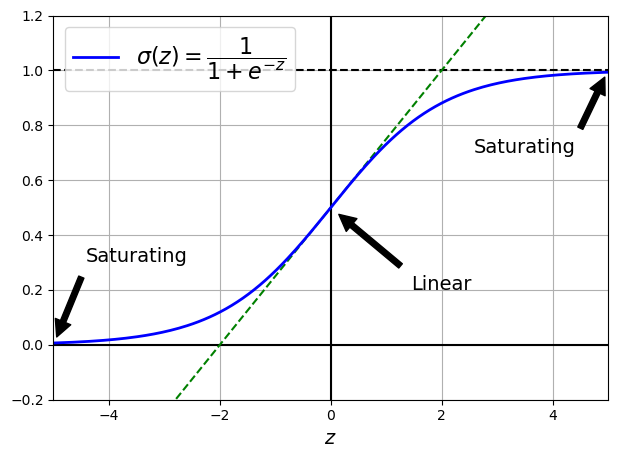

In [6]:
# extra code – this cell generates and saves Figure 11–1

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

save_fig("sigmoid_saturation_plot")
plt.show()

This plot illustrates the **sigmoid activation function** ($\sigma(z) = \frac{1}{1 + e^{-z}}$), which is commonly used in neural networks but *suffers from the vanishing gradients problem* in deep networks. The function **saturates (becomes flat) at extreme values of $z$ (near -5 and +5)**, where the derivative approaches 0. This causes gradients to vanish during backpropagation, slowing learning in deep layers. The annotations highlight the "saturating" regions and the "linear" region around $z=0$, where gradients are stronger. This visualization supports the discussion on why better initialization and activation functions are needed for deep networks.

---

## Xavier (Glorot) and He (Kaiming) Initialization

To mitigate the vanishing/exploding gradients problem, we can use specialized weight initialization methods like **Xavier (Glorot) initialization** for activation functions like tanh and sigmoid, and **He (Kaiming) initialization** for ReLU and its variants. These methods help maintain a stable variance of activations and gradients throughout the network.

### Typical Initialization

First, let's create a dense layer with ReLU activation and He normal initialization:

In [7]:
dense = tf.keras.layers.Dense(50, activation="relu",
                              kernel_initializer="he_normal")

This code creates a dense (fully connected) layer with 50 neurons, using the ReLU activation function and He normal initialization for the weights. He initialization helps prevent vanishing gradients in deep networks by scaling the weights appropriately for ReLU activations, maintaining stable variance across layers. This is a common technique for training deep neural networks effectively.
`kernel_initializer="he_normal"` specifies that the weights should be initialized using the He normal method.

built layer: <Dense name=dense, built=True>
kernel initializer distribution: truncated_normal
theoretical stddev: 0.31622776601683794
kernel shape: (20, 50) bias shape: (50,)
kernel mean: -0.01651238 std: 0.30559763
first 10 values: [ 0.0404 -0.1065 -0.4175 -0.1952 -0.3242 -0.4307 -0.3894  0.1846 -0.0129
 -0.126 ]


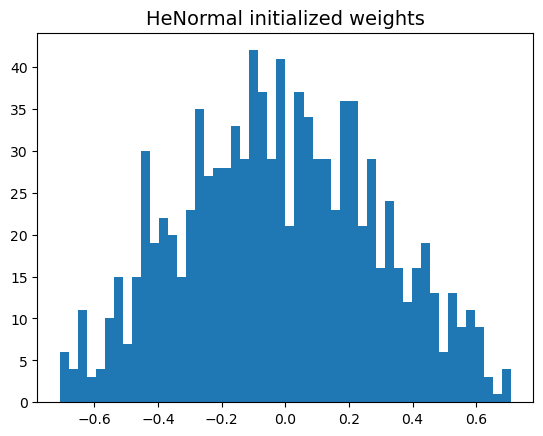

In [8]:
def show_initial_weights(layer, input_shape, fan_in=None):
    """Build `layer` (if not yet built), print some stats and draw a histogram.

    Args:
        layer: a Keras layer instance (Dense, Conv2D, …).
        input_shape: shape tuple (batch dim may be None) to build the layer.
        fan_in: optional integer; only used when the initializer expects it
                (e.g. `mode='fan_in'`) or to override the automatic value.
    """
    layer.build(input_shape)
    print("built layer:", layer)

    # infer fans from the kernel shape
    kernel_shape = layer.kernel.shape
    inferred_fan_in = int(kernel_shape[0])
    inferred_fan_out = int(kernel_shape[1])
    if fan_in is None:
        fan_in = inferred_fan_in

    # try to compute a theoretical stddev according to the initializer
    init = layer.kernel_initializer
    stddev = None
    if isinstance(init, tf.keras.initializers.VarianceScaling):
        scale, mode, dist = init.scale, init.mode, init.distribution

        # choose the appropriate “fan” depending on the mode
        if mode == "fan_in":
            divisor = fan_in
        elif mode == "fan_out":
            divisor = inferred_fan_out
        elif mode == "fan_avg":                     # <‑‑ new case
            divisor = (fan_in + inferred_fan_out) / 2
        else:
            divisor = fan_in         # should not happen

        # variance = scale / divisor for both normal and uniform,
        # but if the distribution is uniform we can also report the
        # limit that Keras uses (a = √(3·scale/divisor)).
        stddev = np.sqrt(scale / divisor)
        print("kernel initializer distribution:", dist)
        if dist == "uniform":
            limit = np.sqrt(3.0 * scale / divisor)
            print("uniform limit:", limit)
    elif init.__class__.__name__.lower().startswith("he"):
        # fair approximation for He initializers
        stddev = np.sqrt(2.0 / fan_in)

    if stddev is not None:
        print("theoretical stddev:", stddev)

    print("kernel shape:", layer.kernel.shape,
          "bias shape:", layer.bias.shape)

    kernel, bias = layer.get_weights()
    print("kernel mean:", kernel.mean(), "std:", kernel.std())
    print("first 10 values:", np.round(kernel.flatten()[:10], 4))

    plt.hist(kernel.flatten(), bins=50)
    plt.title(f"{layer.kernel_initializer.__class__.__name__} initialized weights")
    plt.show()

fan_in = 20
show_initial_weights(dense, input_shape=(None, 20), fan_in=fan_in)

The `.kernel_initializer` object itself also exposes its configuration;
you can query `dense.kernel_initializer` for the seed, scale, etc., and even
call it manually to sample a tensor:

In [9]:
init = tf.keras.initializers.he_normal()
w = init(shape=(fan_in, 50))
print(w.numpy().std(), np.sqrt(2.0 / fan_in))

0.3029078 0.31622776601683794


### Custom Initialization

Furthermore, a custom He initialization variant for a dense layer using the sigmoid activation function is instantiated. The `VarianceScaling` initializer is configured with `scale=2.0` (suitable for sigmoid, which is similar to Xavier/Glorot initialization), `mode="fan_avg"` (averages fan-in and fan-out), and `distribution="uniform"` for uniform weight distribution. This helps stabilize gradients in deep networks, though He initialization is more commonly used with ReLU. The layer has 50 neurons and sigmoid activation.

In [10]:
he_avg_init = tf.keras.initializers.VarianceScaling(scale=2., mode="fan_avg",
                                                    distribution="uniform")
dense = tf.keras.layers.Dense(50, activation="sigmoid",
                              kernel_initializer=he_avg_init)

built layer: <Dense name=dense_1, built=True>
kernel initializer distribution: uniform
uniform limit: 0.4140393356054125
theoretical stddev: 0.23904572186687872
kernel shape: (20, 50) bias shape: (50,)
kernel mean: -0.0019838044 std: 0.23737985
first 10 values: [ 0.2898  0.1017  0.0437 -0.2723  0.093   0.0192 -0.3904 -0.2594  0.0331
 -0.2142]


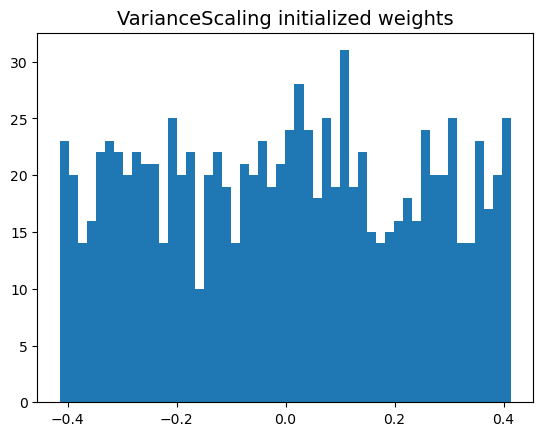

In [11]:
show_initial_weights(dense, input_shape=(None, 20), fan_in=fan_in)

Secondly, we can use **Xavier initialization** for a dense layer with the tanh activation function as follows:


In [12]:
from tensorflow import keras
layer = keras.layers.Dense(
    50,
    activation="tanh",
    kernel_initializer=keras.initializers.GlorotUniform(),
)

where `kernel_initializer=keras.initializers.GlorotUniform()` specifies Xavier uniform initialization. Equivalently, you could use `GlorotNormal()` for normal distribution.

built layer: <Dense name=dense_2, built=True>
kernel initializer distribution: uniform
uniform limit: 0.29277002188455997
theoretical stddev: 0.1690308509457033
kernel shape: (20, 50) bias shape: (50,)
kernel mean: 0.0026898538 std: 0.16587104
first 10 values: [-0.007  -0.0464 -0.0495  0.0197 -0.2555 -0.1012 -0.0433 -0.0649  0.1758
  0.1484]


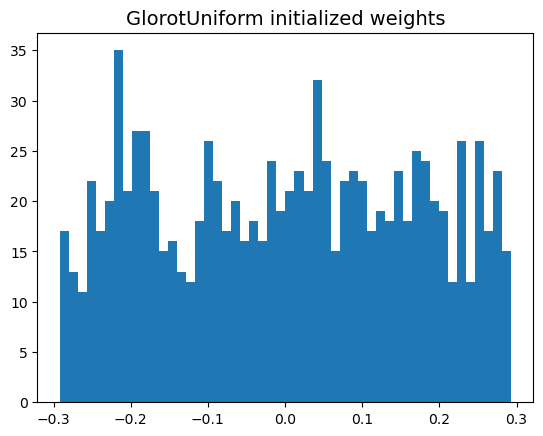

In [13]:
show_initial_weights(layer, input_shape=(None, 20), fan_in=fan_in)

In [14]:
layer = keras.layers.Dense(
    50,
    activation="sigmoid",
    kernel_initializer=keras.initializers.VarianceScaling(
        scale=2.0, mode="fan_avg", distribution="uniform"
    ),
)

built layer: <Dense name=dense_3, built=True>
kernel initializer distribution: uniform
uniform limit: 0.4140393356054125
theoretical stddev: 0.23904572186687872
kernel shape: (20, 50) bias shape: (50,)
kernel mean: -0.0037527462 std: 0.237375
first 10 values: [-0.3614 -0.1799  0.1106  0.0753  0.174  -0.332  -0.1629 -0.1789  0.3407
 -0.2075]


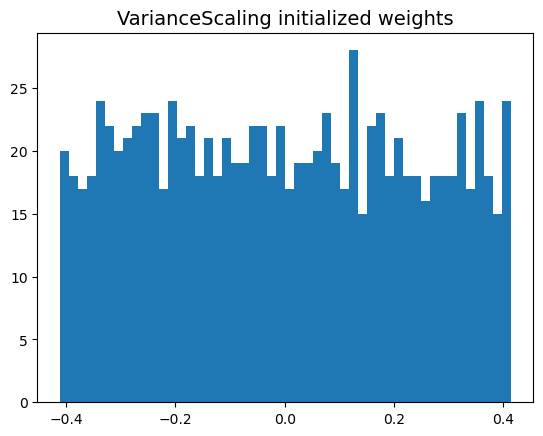

In [15]:
show_initial_weights(layer, input_shape=(None, 20), fan_in=fan_in)

This code creates a dense layer with 50 neurons using the sigmoid activation function and a custom Xavier initialization variant. The `VarianceScaling` initializer is set with `scale=2.0` (appropriate for sigmoid, matching Xavier/Glorot scaling), `mode="fan_avg"` (averaging fan-in and fan-out), and `distribution="uniform"` for uniform weight distribution. This helps stabilize gradients in deep networks, though Xavier is typically used with tanh or sigmoid. The layer is defined using TensorFlow's Keras API.

### Conclusion

- He initialization is especially appropriate for neural networks
  using ReLU activations, as it helps keep the signals stable during
  forward and backward propagation, promoting faster convergence and
  better performance.  
  `he_normal` is one implementation of He initialization; it samples
  weights from a normal distribution whose **variance** is computed
  from the number of incoming connections (`fan_in`):

$$ \mathrm{Var(W)} = \frac{2}{\text{fan\_in}}$$

- Xavier initialization is suitable for networks using Sigmoid or Tanh
  activations, because it helps maintain stable signal variance during
  forward and backward passes.  
  The variance in this case is

 $$ \mathrm{Var(W)} = \frac{1}{\text{fan\_in}}
\qquad\text{(or, equivalently, }
 \mathrm{Var(W)} = \frac{2}{\text{fan\_in} + \text{fan\_out}}\text{)}$$

According to the chosen probability distribution, the initialization
parameters are set as follows:

* **Normal distribution** – weights are drawn from  
  $\mathcal{N}(0,\sigma^2)$ with  
  $$\sigma = \sqrt{\frac{2}{\,n_{\text{in}}+n_{\text{out}}\,}}\;.$$
* **Uniform distribution** – weights are sampled uniformly from $[-r,r]$
  where  
  $$r = \sqrt{\frac{6}{\,n_{\text{in}}+n_{\text{out}}\,}}\;.$$

---

## Nonsaturating Activation Functions

Using nonsaturating activation functions like ReLU and its variants (Leaky ReLU, ELU, SELU) helps mitigate the vanishing gradients problem. These functions do not saturate for positive inputs, allowing gradients to flow more easily through deep networks.

### Leaky ReLU

This code creates a dense layer with 50 neurons using the Leaky ReLU activation function, which allows a small, non-zero gradient when the input is negative. This helps prevent neurons from "dying" during training, addressing issues associated with the standard ReLU function.

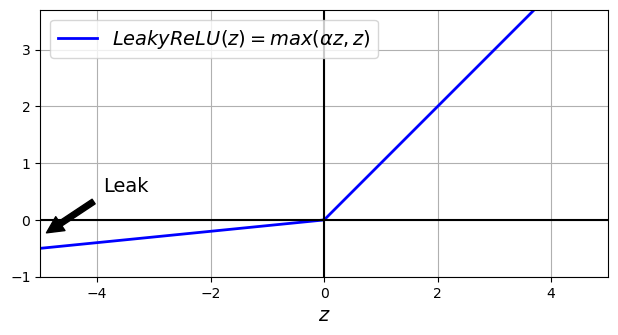

In [16]:
# extra code – this cell generates and saves Figure 11–2

def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

save_fig("leaky_relu_plot")
plt.show()

This plot displays the **Leaky ReLU activation function**, defined as $max(\alpha z, z)$, where $\alpha$ (alpha) is a small positive constant (typically 0.1, as indicated by the plot's slope for $z < 0$).

Unlike the standard ReLU function which outputs 0 for negative inputs, Leaky ReLU allows a small, non-zero gradient for negative values. This "leak" (highlighted in the annotation) prevents neurons from becoming inactive (or "dying") when their input is negative, which can happen with standard ReLU. By maintaining a non-zero gradient across all inputs, Leaky ReLU helps mitigate the **vanishing gradients problem** and allows for more stable and efficient training of deep neural networks.

`tf.keras.layers.LeakyReLU` is not a function but a
**layer‑class** implementing the leaky rectified linear unit.  
You first instantiate it (optionally passing `alpha=…`), which gives you an
object you can plug into a model in two equivalent ways:

* **Standalone layer** – place it after a `Dense`, `Conv2D`, … layer that
    was built *without* an activation.
* **Activation function** – pass it as the `activation` argument when
    building a layer.

In [17]:
leaky_relu = tf.keras.layers.LeakyReLU(alpha=0.2)  # defaults to alpha=0.2
dense = tf.keras.layers.Dense(50, activation=leaky_relu,
                              kernel_initializer="he_normal")

c:\Users\yuanh\miniconda3\envs\homl3\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [18]:
model = tf.keras.models.Sequential([
    # [...]  # more layers
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),  # no activation
    tf.keras.layers.LeakyReLU(alpha=0.2),  # activation as a separate layer
    # [...]  # more layers
])

### ELU (Exponential Linear Unit)

This code creates a dense layer with 50 neurons using the **Exponential Linear Unit (ELU)** activation function. ELU helps mitigate the vanishing gradients problem by allowing negative outputs for negative inputs, which helps maintain a non-zero gradient. This can lead to faster convergence and improved performance in deep neural networks compared to standard ReLU.
The ELU is defined as:

$$
\mathrm{ELU}_\alpha(z)=
\begin{cases}
z & \text{if } z \ge 0,\\[6pt]
\alpha\big(e^{z}-1\big) & \text{if } z < 0,
\end{cases}
$$

and its derivative is

$$
\mathrm{ELU}'_\alpha(z)=
\begin{cases}
1 & \text{if } z \ge 0,\\[6pt]
\alpha\,e^{z} & \text{if } z < 0.
\end{cases}
$$

Notes: the negative part is bounded below by −α, the derivative is continuous at 0 when α = 1 (the common default), and ELU yields nonzero gradients for z < 0, helping training stability.

Implementing ELU in TensorFlow is trivial, just specify the activation function when building each layer, and use He initialization:

In [19]:
dense = tf.keras.layers.Dense(50, activation="elu",
                              kernel_initializer="he_normal")

You don’t have to stick with `LeakyReLU` – you can switch to ELU and
tune its `alpha` parameter directly. `tf.keras.layers.ELU` is a layer
class, so you can either instantiate it and pass the object as the
`activation`, or create it inline.

For example, to use an ELU with `alpha=0.5` (the default is `1.0`):


In [20]:
model = tf.keras.models.Sequential([
    # ...existing code...
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),  # no activation
    tf.keras.layers.ELU(alpha=0.5),  # ELU activation as a separate layer with custom alpha
    # ...existing code...
])

### SELU (Scaled ELU)

By default, the SELU hyperparameters (`scale` and `alpha`) are tuned in such a way that the mean output of each neuron remains close to 0, and the standard deviation remains close to 1 (assuming the inputs are standardized with mean 0 and standard deviation 1 too, and other constraints are respected, as explained in the book). Using this activation function, even a 1,000 layer deep neural network preserves roughly mean 0 and standard deviation 1 across all layers, avoiding the exploding/vanishing gradients problem:

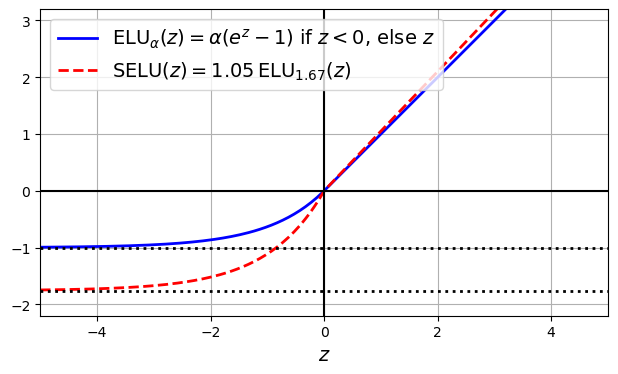

In [21]:
# extra code – this cell generates and saves Figure 11–3

from scipy.special import erfc

# alpha and scale to self normalize with mean 0 and standard deviation 1
# (see equation 14 in the paper):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis((-5, 5, -2.2, 3.2))
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

save_fig("elu_selu_plot")
plt.show()

Using SELU is straightforward:

In [22]:
dense = tf.keras.layers.Dense(50, activation="selu",
                              kernel_initializer="lecun_normal")

You would typically integrate it directly into the `Dense` layer definition, along with `lecun_normal` initialization, as this combination is crucial for achieving the self-normalizing properties of SELU.

**Extra material – an example of a self-regularized network using SELU**

Let's create a neural net for Fashion MNIST with 100 hidden layers, using the SELU activation function:

In [23]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(28, 28)))
model.add(tf.keras.layers.Flatten())
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="selu",
                                    kernel_initializer="lecun_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [24]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

Now let's train it. Do not forget to scale the inputs to mean 0 and standard deviation 1:

In [5]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

In [6]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [7]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [28]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.5731 - loss: 1.1255 - val_accuracy: 0.7300 - val_loss: 0.7837
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7379 - loss: 0.7344 - val_accuracy: 0.7550 - val_loss: 0.6806
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7778 - loss: 0.6172 - val_accuracy: 0.7498 - val_loss: 0.6851
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7947 - loss: 0.5731 - val_accuracy: 0.7990 - val_loss: 0.5950
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8145 - loss: 0.5360 - val_accuracy: 0.8002 - val_loss: 0.5547


In [29]:
# extra code – this cell defines a new function to compute and print gradients for a specific layer
def compute_layer_gradients(model, target_layer, X_sample, y_sample):
    """
    Computes and prints the gradients of the loss with respect to the trainable
    variables of a specific target layer for a given sample of data.

    Args:
        model (tf.keras.Model): The Keras model.
        target_layer (tf.keras.layers.Layer): The layer for which to compute gradients.
        X_sample (tf.Tensor): A small batch of input features for demonstration.
        y_sample (tf.Tensor): A small batch of corresponding labels for demonstration.

    Returns:
        list: A list of gradients (tf.Tensor) for each trainable variable in the
              target_layer. Returns an empty list if the layer has no trainable
              variables or if gradients cannot be computed.
    """
    if not target_layer.trainable_variables:
        print(f"Layer '{target_layer.name}' does not have trainable variables to compute gradients for.")
        return []

    # Instantiate the loss function for direct calculation
    # Since the model uses 'softmax' activation in the output layer, from_logits should be False (default)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    with tf.GradientTape() as tape:
        # Forward pass: get the model's predictions
        y_pred = model(X_sample, training=True)
        # Calculate the loss using the instantiated loss function
        loss = loss_fn(y_sample, y_pred)

    # Get gradients of the loss with respect to the trainable variables of the target layer
    trainable_vars_of_layer = target_layer.trainable_variables
    gradients = tape.gradient(loss, trainable_vars_of_layer)

    print(f"\nGradients for layer '{target_layer.name}':")
    for var, grad in zip(trainable_vars_of_layer, gradients):
        print(f"  Variable: {var.name}")
        print(f"  Shape: {var.shape}")
        if grad is not None:
            print(f"  Gradient (first 5 elements): {grad.numpy().flatten()[:5]}")
            print(f"  Gradient Norm (L2): {tf.norm(grad).numpy()}")
        else:
            print("  Gradient: None (variable not contributing to this loss path)")
        print("-" * 30)
    
    return gradients

# Example usage of the new function:
# Assuming 'model', 'X_train_scaled', 'y_train' are defined from previous cells.
# Get the first Dense layer (model.layers[1] in your current setup)
target_layer_selu = model.layers[1]
X_sample = X_train_scaled[:10]
y_sample = y_train[:10]

# Compute and print gradients using the refactored function
computed_gradients_selu = compute_layer_gradients(model, target_layer_selu, X_sample, y_sample)


Gradients for layer 'dense_9':
  Variable: kernel
  Shape: (784, 100)
  Gradient (first 5 elements): [ 8.2722501e-05  1.4144437e-04 -1.7590293e-04 -5.0527501e-06
  1.9569130e-04]
  Gradient Norm (L2): 4.5733795166015625
------------------------------
  Variable: bias
  Shape: (100,)
  Gradient (first 5 elements): [-0.00972603 -0.0166302   0.02068164  0.00059407 -0.02300825]
  Gradient Norm (L2): 0.1971282660961151
------------------------------


The network managed to learn, despite how deep it is. Now look at what happens if we try to use the ReLU activation function instead:

In [30]:
tf.random.set_seed(42)

In [31]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="relu",
                                    kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [32]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

In [33]:
history = model.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.2244 - loss: 1.9612 - val_accuracy: 0.3008 - val_loss: 1.6099
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3499 - loss: 1.5124 - val_accuracy: 0.2308 - val_loss: 1.7530
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4990 - loss: 1.1733 - val_accuracy: 0.5906 - val_loss: 0.9647
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5921 - loss: 0.9641 - val_accuracy: 0.6442 - val_loss: 0.8258
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6194 - loss: 0.8877 - val_accuracy: 0.6712 - val_loss: 0.7925


Not great at all, we suffered from the vanishing/exploding gradients problem.

In [34]:
target_layer_relu = model.layers[1]

# Compute and print gradients using the refactored function
computed_gradients_relu = compute_layer_gradients(model, target_layer_relu, X_sample, y_sample)


Gradients for layer 'dense_110':
  Variable: kernel
  Shape: (784, 100)
  Gradient (first 5 elements): [ 0.00012888 -0.00021398  0.00032596 -0.00069409  0.00047228]
  Gradient Norm (L2): 10.456899642944336
------------------------------
  Variable: bias
  Shape: (100,)
  Gradient (first 5 elements): [-0.01515255  0.02515802 -0.03832477  0.08160692 -0.05552801]
  Gradient Norm (L2): 0.599709153175354
------------------------------


In [35]:
model.layers[1].get_weights()[0]

array([[ 0.00772185,  0.05023415,  0.02750352, ..., -0.07071639,
         0.06211734, -0.00857724],
       [-0.01444577, -0.01474735,  0.06175869, ...,  0.08000445,
         0.0559632 ,  0.0133218 ],
       [ 0.01548617, -0.03651585, -0.01235415, ..., -0.04871281,
         0.00410398,  0.02595073],
       ...,
       [ 0.04065197, -0.07267689,  0.08521839, ..., -0.0028618 ,
         0.05819713,  0.03396648],
       [-0.01342931,  0.09992807, -0.04817185, ...,  0.04828665,
        -0.05048661, -0.06299952],
       [-0.00239486,  0.01192451, -0.11093112, ...,  0.08683292,
        -0.00294704, -0.02769259]], dtype=float32)

### GELU, Swish and Mish

The **GELU (Gaussian Error Linear Unit)** activation function is a smooth, non-linear activation function that combines properties of *ReLU and sigmoid functions*. It helps mitigate the vanishing gradients problem by allowing small negative outputs, which can improve training stability and performance in deep neural networks.

where the GELU activation is defined as:
$$\mathrm{GELU}(z) = 0.5z\left(1 + \mathrm{tanh}\left[\sqrt{\frac{2}{\pi}}\left(z + 0.044715z^3\right)\right]\right)$$


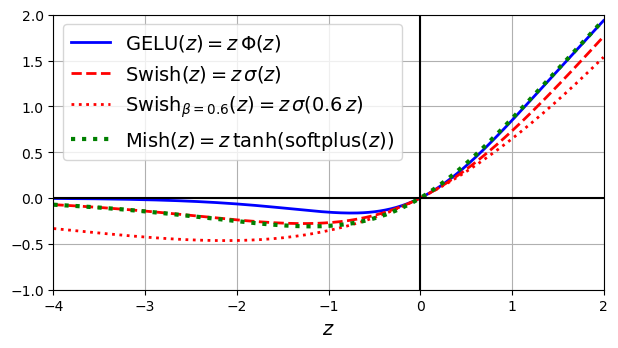

In [36]:
# extra code – this cell generates and saves Figure 11–4

def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

z = np.linspace(-4, 2, 200)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "g:", linewidth=3,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

save_fig("gelu_swish_mish_plot")
plt.show()

This plot compares three smooth, non‑saturating activations (and a Swish variant) over z ∈ [−4, 2]:

- Blue (approx GELU): GELU ≈ z·Φ(z). smooth, nearly linear for positive z, yields small negative outputs for negative z — used in Transformers (BERT).  
- Red (Swish, β=1 — dashed; β=0.6 — dotted): swish(z)=z·σ(βz). smooth, can be non‑monotonic; β controls the “leak” for negatives (smaller β → smaller negative response). Swish with β≈1.702 closely approximates GELU.  
- Green (Mish): z·tanh(softplus(z)). smooth, non‑monotonic, produces mild negative tail and very smooth transitions.

Key observations and practical implications
- All three preserve nonzero gradients for negative inputs (unlike ReLU), improving gradient flow and representation richness in deep nets.  
- Differences are subtle for moderate z but can affect optimization dynamics and generalization; non‑monotonicity can act like a mild implicit regularizer.  
- Computational cost: GELU/Swish/Mish > ReLU; GELU and Swish are commonly implemented and well‑optimized (GELU standard in NLP; Swish used in state‑of‑the‑art vision nets like EfficientNet). Mish is promising but less ubiquitous.  
- Recommendation: prefer GELU for Transformer/NLP work, try Swish (tune β) for vision, consider Mish as an experimental alternative — always validate on your task and monitor training speed and generalization.

---

# Batch Normalization

Batch normalization **standardizes the inputs to each layer**, stabilizing learning and allowing for higher learning rates. It helps mitigate internal covariate shift, improving convergence speed and model performance.

In [37]:
# extra code - clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [38]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.BatchNormalization(), # standardize inputs
    tf.keras.layers.Dense(300, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(), # standardize inputs
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(), # standardize inputs
    tf.keras.layers.Dense(10, activation="softmax")
])

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [40]:
[(var.name, var.trainable) for var in model.layers[1].variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

In [41]:
# extra code – just show that the model works! 😊
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8079 - loss: 0.5478 - val_accuracy: 0.8520 - val_loss: 0.3990
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8598 - loss: 0.3939 - val_accuracy: 0.8644 - val_loss: 0.3662


In [42]:
[(var.name, var.trainable) for var in model.layers[1].variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

Sometimes applying BN *before the activation function works better* (there's a debate on this topic). Moreover, the layer before a `BatchNormalization` layer does not need to have bias terms, since the `BatchNormalization` layer some as well, it would be a waste of parameters, so you can set `use_bias=False` when creating those layers:

In [43]:
# extra code - clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [44]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(), # BN before activation
    tf.keras.layers.Activation("relu"),
    
    tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(), # BN before activation
    tf.keras.layers.Activation("relu"),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

In [45]:
# extra code – just show that the model works! 😊
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7990 - loss: 0.6027 - val_accuracy: 0.8476 - val_loss: 0.4212
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8542 - loss: 0.4214 - val_accuracy: 0.8630 - val_loss: 0.3763


## Gradient Clipping

To prevent exploding gradients during training, we can use gradient clipping. This technique limits the maximum value of gradients, ensuring stable updates to the model weights.

All `tf.keras.optimizers` accept `clipnorm` or `clipvalue` arguments:

In [46]:
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

### `clipnorm` (concise explanation)

- What it does  
  Clips the global $\ell_2$ norm of the gradient vector for an update. If the total gradient norm $\lVert g\rVert_2$ exceeds the threshold $c$, all gradients are rescaled by $c / \lVert g\rVert_2$:

  $$
  g \leftarrow
  \begin{cases}
    g, & \text{if }\ \lVert g\rVert_2 \le c,\\[6pt]
    g \cdot \dfrac{c}{\lVert g\rVert_2}, & \text{otherwise.}
  \end{cases}
  $$

- How Keras applies it  
  `tf.keras` uses a global‑norm clip (`tf.clip_by_global_norm`) on the gradients computed for the current batch — i.e., it scales the whole gradient tuple together (based on $\lVert g\rVert_2$).

- Difference vs. `clipvalue`  
  - `clipnorm`: rescales the entire gradient vector when its $\ell_2$ norm is too large (preserves direction).  
  - `clipvalue`: clips each gradient component element‑wise to the range $[-c,\,c]$ (may change direction).

- When to use  
  - Prevent exploding gradients (RNNs, very deep nets, unstable training).  
  - Use when you observe very large gradient norms or unstable loss/weight updates.

- Typical settings and tips
  - Common starting value: `clipnorm ≈ 1.0` (tune for your model).  
  - Works with any optimizer (SGD, Adam, etc.).  
  - Does not fix vanishing gradients — only bounds explosion.  
  - Monitor gradient norms with e.g. `tf.linalg.global_norm` to choose an appropriate threshold.

- Keras example  
  - `optimizer = tf.keras.optimizers.SGD(clipnorm=1.0)`

In [47]:
optimizer = tf.keras.optimizers.SGD(clipnorm=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

## Reusing Pretrained Layers

### Reusing a Keras model

Let's split the fashion MNIST training set in two:
* `X_train_A`: all images of all items except for T-shirts/tops and pullovers (classes 0 and 2).
* `X_train_B`: a much smaller training set of just the first 200 images of T-shirts/tops and pullovers.

The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (trousers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots) are somewhat similar to classes in set B (T-shirts/tops and pullovers). However, since we are using `Dense` layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image, as we will see in the chapter 14).

In [48]:
# extra code – split Fashion MNIST into tasks A and B, then train and save
#              model A to "my_model_A".

pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")

def split_dataset(X, y):
    """Split a Fashion‑MNIST dataset into two tasks A and B.

    Task A contains all samples whose label is **not** Pullover or
    T‑shirt/top; the labels are remapped to 0–7 in the order of the
    remaining classes.  
    Task B contains only the Pullover vs. T‑shirt/top examples; its
    labels are binary (1 for Pullover, 0 for T‑shirt/top).

    Args:
        X (np.ndarray): array of input images, shape `(n_samples, …)`.
        y (np.ndarray): array of integer labels in `0..9`, shape
            `(n_samples,)`.

    Returns:
        ((X_A, y_A), (X_B, y_B)):
            * `X_A`, `y_A` – data and 8‑class labels for task A.
            * `X_B`, `y_B` – data and binary labels for task B.
    """
    y_for_B = (y == pos_class_id) | (y == neg_class_id)
    y_A = y[~y_for_B]
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32)
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id]))
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reorder class ids for A
    X_A = X[~y_for_B]
    X_B = X[y_for_B]
    return ((X_A, y_A), (X_B, y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

In [49]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model_A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))
model_A.save("my_model_A.keras")

Epoch 1/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6517 - loss: 1.1219 - val_accuracy: 0.7952 - val_loss: 0.6829
Epoch 2/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8141 - loss: 0.5947 - val_accuracy: 0.8426 - val_loss: 0.5076
Epoch 3/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8505 - loss: 0.4774 - val_accuracy: 0.8654 - val_loss: 0.4335
Epoch 4/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8665 - loss: 0.4177 - val_accuracy: 0.8716 - val_loss: 0.3916
Epoch 5/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8754 - loss: 0.3809 - val_accuracy: 0.8789 - val_loss: 0.3647
Epoch 6/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8810 - loss: 0.3562 - val_accuracy: 0.8822 - val_loss: 0.3463
Epoch 7/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8859 - loss: 0.3383 - val_accuracy: 0.8852 - val_loss: 0.3327
Epoch 8/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8900 - loss: 0.3245 - 

In [50]:
# extra code – train and evaluate model B, without reusing model A

tf.random.set_seed(42)
model_B = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B))
model_B.evaluate(X_test_B, y_test_B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4500 - loss: 0.8212 - val_accuracy: 0.4876 - val_loss: 0.7466
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4600 - loss: 0.7437 - val_accuracy: 0.5005 - val_loss: 0.6932
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4900 - loss: 0.6900 - val_accuracy: 0.5262 - val_loss: 0.6553
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5100 - loss: 0.6512 - val_accuracy: 0.5757 - val_loss: 0.6270
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5850 - loss: 0.6221 - val_accuracy: 0.6400 - val_loss: 0.6046
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6900 - loss: 0.5988 - val_accuracy: 0.7043 - val_loss: 0.5857
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7300 - loss: 0.5789 - val_accuracy: 0.7715 - val_loss: 0.5692
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7850 - loss: 0.5614 - val_accuracy: 0.8160 - val_loss: 0.5544


[0.43673089146614075, 0.9169999957084656]

Model B reaches 91.85% accuracy on the test set. Now let's try reusing the pretrained model A.

In [51]:
# reuse model A to create model B_on_A, then train and evaluate it
model_A = tf.keras.models.load_model("my_model_A.keras")
model_B_on_A = tf.keras.Sequential(model_A.layers[:-1])

# the last layer of model A is a Dense layer with 8 outputs, but we need only 1 output for model B_on_A, so we replace it with a new Dense layer with 1 output and sigmoid activation
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

Note that `model_B_on_A` and `model_A` actually share layers now, so when we train one, it will update both models. If we want to avoid that, we need to build `model_B_on_A` on top of a *clone* of `model_A`:

In [52]:
tf.random.set_seed(42)  # extra code – ensure reproducibility

The cell that follows will re‑seed the RNG and then make a **clone** of `model_A`
before re‑using its layers. Cloning and copying the weights guarantees that the
layers used to build `model_B_on_A` are independent objects, so training the new
model won’t inadvertently update the original `model_A`.

*reset the random seed for reproducibility, clone `model_A`, copy its weights,*
*then slice off its last layer and add a new single‑output Dense layer for task B.*

In [53]:
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

In [54]:
# extra code – creating model_B_on_A just like in the previous cell
model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [55]:
# freeze all layers of model_B_on_A except the last one (the new Dense layer we just added)
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))

Epoch 1/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5550 - loss: 2.3267 - val_accuracy: 0.5153 - val_loss: 1.7170
Epoch 2/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5500 - loss: 1.3596 - val_accuracy: 0.4728 - val_loss: 0.9981
Epoch 3/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4250 - loss: 0.9186 - val_accuracy: 0.3165 - val_loss: 0.8378
Epoch 4/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3450 - loss: 0.8426 - val_accuracy: 0.3719 - val_loss: 0.8110


In [56]:
# unfreeze all layers of model_B_on_A and continue training for a few more epochs
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))

Epoch 1/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3800 - loss: 0.7880 - val_accuracy: 0.5213 - val_loss: 0.7082
Epoch 2/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5200 - loss: 0.6871 - val_accuracy: 0.6113 - val_loss: 0.6294
Epoch 3/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6550 - loss: 0.6088 - val_accuracy: 0.7102 - val_loss: 0.5695
Epoch 4/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7450 - loss: 0.5498 - val_accuracy: 0.7992 - val_loss: 0.5236
Epoch 5/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8200 - loss: 0.5039 - val_accuracy: 0.8318 - val_loss: 0.4871
Epoch 6/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8600 - loss: 0.4672 - val_accuracy: 0.8576 - val_loss: 0.4580
Epoch 7/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9000 - loss: 0.4381 - val_accuracy: 0.8773 - val_loss: 0.4342
Epoch 8/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9100 - loss: 0.4146 - val_accuracy: 0.8843 - val_loss: 0.4145


So, what's the final verdict?

In [57]:
model_B_on_A.evaluate(X_test_B, y_test_B)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9200 - loss: 0.3280  


[0.3279675245285034, 0.9200000166893005]

Great! We got a bit of transfer: the model's accuracy went up 2 percentage points, from 91.85% to 93.85%. This means the error rate dropped by almost 25%:

In [58]:
1 - (100 - 93.85) / (100 - 91.85)

0.24539877300613477

### Conclusion

In this little experiment we split Fashion‑MNIST into two related tasks and
tried to transfer some knowledge from the first to the second:

* task A – an 8‑class problem made of all items **except** T‑shirts and
    pullovers,
* task B – a binary Pullover vs. T‑shirt/top classification with only 200
    training examples.

We trained a small fully‑connected network from scratch on task A, saved it,
and then trained another network from scratch on task B. The “pure” model B
reached about **91.8 %** test accuracy.

Re‑using the pretrained model A for task B (cloning it, slicing off the last
layer, adding a new sigmoid output, freezing the old layers and then
fine‑tuning) gave a clear benefit: after the usual freeze‑then‑unfreeze
schedule the transferred model attained **≈ 93.8 %** accuracy. That’s a
2‑point gain, i.e. roughly a 25 % reduction in error rate, even though only
dense layers were used (so only patterns at the exact same pixel locations
could be shared – convolutional nets would transfer even better).

This illustrates the basic recipe for transfer learning with Keras: split the
data, train a “base” model on a large related task, clone or load it, replace
the final head, optionally freeze its layers, train on the new task, then
unfreeze and fine‑tune. Even when the secondary dataset is small, reusing
pretrained layers can speed convergence and improve generalization.

(And of course, for vision problems you’ll usually transfer convolutional
layers rather than dense ones, which allows learned features to be detected
anywhere in the image.)

---
# Faster Optimizers

Faster optimizers aim to converge in fewer epochs (and with less tuning) while still generalizing well. This section compares popular algorithms, summarizes their trade‑offs, and gives a practical workflow for picking and tuning an optimizer.

Key algorithms (very briefly)
- SGD + momentum / Nesterov — simple, robust; often yields the best final generalization but can be slower to converge. Typical: momentum=0.9.
- RMSProp — adaptive per‑parameter steps; good for noisy/ill‑conditioned problems.
- Adam / AdamW — fast, well‑behaved defaults for prototyping; AdamW decouples weight decay (preferred for regularization).
- Nadam / AMSGrad — small variants that can help stability in some cases.

Practical recipe
- Prototype with Adam (lr ≈ 1e‑3) to find a reasonable model and learning‑rate range.
- For best final results, switch to SGD + momentum (momentum ≈ 0.9) and use a tuned LR schedule (step decay, cosine annealing, or cyclic).
- Use AdamW (not plain Adam with L2) when using decoupled weight decay.
- For large‑batch training use learning‑rate warmup; scale LR proportionally to batch size.
- Clip gradients (clipnorm ≈ 1.0) if you see unstable/very large updates.
- Always perform a small LR sweep (log scale) and run multiple seeds for robustness.

Typical starting hyperparameters
- SGD: lr 0.01–0.1, momentum 0.9
- Adam: lr 1e‑3, beta1=0.9, beta2=0.999, eps=1e‑7–1e‑8
- AdamW: same as Adam, weight_decay ≈ 1e‑2
- RMSProp: lr 1e‑3, rho 0.9

What you will see next
- Automated comparisons (same architecture, same seed) to evaluate convergence speed and final validation accuracy on Fashion MNIST.
- Suggested experiments: LR sweeps, train longer with SGD+momentum, and compare learning curves and wall‑clock time.

Here are the utility functions that will be used to build and train a deep neural network on the Fashion MNIST dataset, facilitating the comparison of different optimization algorithms.

In [59]:
# extra code – a little function to test an optimizer on Fashion MNIST

def build_model(seed=42):
    """Builds a simple neural network model for Fashion MNIST.

    Args:
        seed (int, optional): Random seed for reproducibility. Defaults to 42.

    Returns:
        tf.keras.Sequential: A compiled Keras Sequential model with three dense layers.
    """
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=[28, 28]),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

def build_and_train_model(optimizer):
    """Builds, compiles, and trains a model using the given optimizer.

    Args:
        optimizer: A TensorFlow optimizer instance to use for training.

    Returns:
        A History object containing the training history.
    """
    model = build_model()
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

First, let's use SGD optimizer to train a deep neural network on the Fashion MNIST dataset as a baseline:

In [60]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

In [61]:
history_sgd = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5991 - loss: 1.2653 - val_accuracy: 0.7216 - val_loss: 0.8550
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7387 - loss: 0.7733 - val_accuracy: 0.7686 - val_loss: 0.6866
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7753 - loss: 0.6587 - val_accuracy: 0.7904 - val_loss: 0.6112
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7950 - loss: 0.5974 - val_accuracy: 0.8054 - val_loss: 0.5675
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8084 - loss: 0.5584 - val_accuracy: 0.8136 - val_loss: 0.5387
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8170 - loss: 0.5311 - val_accuracy: 0.8226 - val_loss: 0.5181
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8239 - loss: 0.5107 - val_accuracy: 0.8270 - val_loss: 0.5022
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8286 - loss: 0.4945 - 

## Momentum Optimization

### Core Concept (What it does)
Momentum optimization is designed to accelerate Gradient Descent by simulating the physical behavior of a ball rolling down a hill. While standard Gradient Descent takes small, uniform steps based only on the local gradient, Momentum accumulates a "velocity" from previous steps. This allows the optimizer to gain speed in directions where gradients consistently point toward the minimum and dampen oscillations in "ravines" (narrow valleys where gradients point sharply toward the center rather than down the length). The result is significantly faster convergence and a better ability to escape shallow local minima.

### Update Rule
The algorithm maintains a velocity vector $\mathbf{v}$ that is updated at each step, and this velocity is then used to update the model parameters $\boldsymbol{\theta}$:

1.  **Update Velocity:**
    $$
    \mathbf{v} \leftarrow \beta \mathbf{v} + \eta \nabla_\theta \mathcal{L}(\theta)
    $$
2.  **Update Parameters:**
    $$
    \theta \leftarrow \theta - \mathbf{v}
    $$
    **Notation:**
    *   $\nabla_\theta \mathcal{L}(\theta)$: The gradient of the loss function at the current position.
    *   $\mathbf{v}$: The velocity (momentum) vector, representing the accumulated history of updates.
    *   $\beta$: The momentum coefficient (hyperparameter), typically set to $0.9$. It acts as a fraction term, determining how much of the previous velocity is retained.
    *   $\eta$: The learning rate.
    *   $\boldsymbol{\theta}$: The model parameters being updated.

### Practical Settings and Tips
*   **Common Hyperparameter Values:**
    *   Momentum Coefficient ($\beta$): Usually set to $0.9$ (retaining 90% of the previous velocity).
    *   Learning Rate ($\eta$): Generally requires careful tuning alongside $\beta$.
*   **The "Overshooting" Risk:** If $\beta$ is too close to $1.0$ (e.g., $0.999$), the optimizer may gain too much speed and overshoot the minimum, leading to prolonged oscillations before finally converging.
*   **Implementation:** In Keras, Momentum is implemented as part of the SGD optimizer:
    ```python
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
    ```
    where `momentum=0.9` is the default value and it represents the fraction of the previous velocity that is retained in the current update.
*   **Generalization:** SGD with Momentum is often the preferred choice for final production models because it tends to find flatter minima that generalize better than adaptive methods like Adam, provided the learning rate schedule is well-tuned.

In [62]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

where `learning_rate` is the step size $\eta$ for updating the model parameters, and `momentum` is the coefficient $\beta$ that determines how much of the previous update's velocity to retain. A common choice for momentum is around 0.9, which means that 90% of the previous velocity is retained in the current update.

In [63]:
history_momentum = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7626 - loss: 0.6925 - val_accuracy: 0.8124 - val_loss: 0.5075
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8355 - loss: 0.4692 - val_accuracy: 0.8354 - val_loss: 0.4518
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8518 - loss: 0.4222 - val_accuracy: 0.8484 - val_loss: 0.4153
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8620 - loss: 0.3935 - val_accuracy: 0.8568 - val_loss: 0.3903
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8689 - loss: 0.3728 - val_accuracy: 0.8622 - val_loss: 0.3759
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8731 - loss: 0.3569 - val_accuracy: 0.8650 - val_loss: 0.3647
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8774 - loss: 0.3436 - val_accuracy: 0.8642 - val_loss: 0.3600
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8812 - loss: 0.3325 - 

## Nesterov Accelerated Gradient (NAG)

### Core Concept (What it does)
Nesterov Accelerated Gradient is a powerful variant of **Momentum optimization** that "looks ahead" before making an update. While standard Momentum computes the gradient at the current position, NAG computes the gradient at an anticipated future position—slightly further in the direction of the momentum. This "look-ahead" mechanism allows the optimizer to adjust its course more intelligently, resulting in significantly faster convergence and reduced overshooting in many optimization landscapes.

### Update Rule
The parameter update in NAG involves calculating the gradient at the predicted future position of the parameters ($\boldsymbol{\theta} + \beta \mathbf{v}$):

1.  **Compute Velocity (with Look-ahead Gradient):**
    $$
    \mathbf{v} \leftarrow \beta \mathbf{v} - \eta \nabla_\theta \mathcal{L}(\theta + \beta \mathbf{v})
    $$
2.  **Update Parameters:**
    $$
    \theta \leftarrow \theta + \mathbf{v}
    $$
    **Notation:**
    *   $\mathcal{L}(\theta + \beta \mathbf{v})$: The loss function evaluated at the "look-ahead" position.
    *   $\mathbf{v}$: The velocity (momentum) vector.
    *   $\beta$: The momentum coefficient (hyperparameter), typically set to $0.9$.
    *   $\eta$: The learning rate.
    *   $\boldsymbol{\theta}$: The model parameters.

### Practical Settings and Tips
*   **Common Hyperparameter Values:**
    *   Momentum Coefficient ($\beta$): Usually $0.9$.
    *   Learning Rate ($\eta$): Depends on the task, but often paired with a learning rate schedule.
*   **Performance Advantage:** NAG almost always outperforms standard momentum optimization, especially in convex problems. It effectively "slows down" the optimizer as it approaches a minimum, preventing the heavy oscillations that often plague standard momentum.
*   **Implementation:** In Keras, you can enable NAG by setting `nesterov=True` within the SGD optimizer:
    ```python
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
    ```
*   **Generalization:** Like SGD with Momentum, NAG is often favored for its strong final generalization performance when the learning rate is properly tuned.

In [64]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9,
                                    nesterov=True) # use Nesterov Accelerated Gradient

In [65]:
history_nesterov = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7662 - loss: 0.6839 - val_accuracy: 0.8278 - val_loss: 0.4889
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8368 - loss: 0.4631 - val_accuracy: 0.8416 - val_loss: 0.4396
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8529 - loss: 0.4196 - val_accuracy: 0.8468 - val_loss: 0.4190
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8619 - loss: 0.3932 - val_accuracy: 0.8518 - val_loss: 0.4048
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8668 - loss: 0.3744 - val_accuracy: 0.8562 - val_loss: 0.3940
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8715 - loss: 0.3590 - val_accuracy: 0.8596 - val_loss: 0.3838
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8762 - loss: 0.3462 - val_accuracy: 0.8600 - val_loss: 0.3792
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8803 - loss: 0.3350 - 

## AdaGrad Optimization

### Core Concept (What it does)
AdaGrad (Adaptive Gradient Algorithm) is an optimizer that automatically scales the learning rate for each parameter individually based on the history of gradients. It achieves this by tracking the sum of the squares of all past gradients. Parameters that receive large and frequent updates have their learning rates scaled down more aggressively, while parameters that receive small or infrequent updates maintain a higher learning rate. This makes AdaGrad particularly effective for handling **sparse data** (where most features are zero most of the time), as it ensures that rarely occurring but informative features still receive significant updates.

### Update Rule
AdaGrad maintains an accumulator $\mathbf{s}_t$ that stores the sum of the squares of the gradients up to time step $t$:

1.  **Accumulate Squared Gradients:**
    $$
    \mathbf{s}_t = \mathbf{s}_{t-1} + \mathbf{g}_t^2
    $$
2.  **Update Parameters:**
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\mathbf{s}_t} + \epsilon} \mathbf{g}_t
    $$
    **Notation:**
    *   $\mathbf{g}_t$: The gradient at time step $t$.
    *   $\mathbf{s}_t$: The accumulated sum of squared gradients (acts as a per-parameter learning rate scaler).
    *   $\eta$: The initial learning rate.
    *   $\epsilon$: A small constant (e.g., $1e^{-7}$) to prevent division by zero.
    *   $\boldsymbol{\theta}$: The model parameters being updated.
    *   as a result, the effective learning rate for each parameter is $\eta / (\sqrt{\mathbf{s}_t} + \epsilon)$, which decreases over time for parameters with large accumulated gradients.

### Practical Settings and Tips
*   **Common Hyperparameter Values:**
    *   Initial Learning Rate ($\eta$): Often set to $0.01$, though it requires tuning for specific problems.
    *   Numerical Stability Constant ($\epsilon$): Typically $1e^{-7}$.
*   **Strength in Sparsity:** AdaGrad excels in tasks with high-dimensional sparse inputs, such as **Natural Language Processing (NLP)** or recommendation systems, where some features are much rarer than others.
*   **The "Vanishing Learning Rate" Limitation:** Because $\mathbf{s}_t$ accumulates squares (which are always positive), the denominator $\sqrt{\mathbf{s}_t}$ grows monotonically. In deep neural networks, this often causes the learning rate to decrease too quickly, effectively stopping the model from learning before it reaches the global optimum.
*   **Successors:** Due to the vanishing learning rate issue, **RMSProp** and **Adam** are generally preferred for training deep neural networks, as they use a moving average to prevent the accumulator from growing indefinitely.

In [66]:
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)

In [67]:
history_adagrad = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6741 - loss: 1.0117 - val_accuracy: 0.7710 - val_loss: 0.6790
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7884 - loss: 0.6329 - val_accuracy: 0.8032 - val_loss: 0.5798
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8110 - loss: 0.5640 - val_accuracy: 0.8164 - val_loss: 0.5351
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8214 - loss: 0.5281 - val_accuracy: 0.8232 - val_loss: 0.5085
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8291 - loss: 0.5050 - val_accuracy: 0.8254 - val_loss: 0.4902
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8350 - loss: 0.4884 - val_accuracy: 0.8290 - val_loss: 0.4768
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8398 - loss: 0.4757 - val_accuracy: 0.8330 - val_loss: 0.4662
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8435 - loss: 0.4655 - 

## RMSProp Optimization

### Core Concept (What it does)
RMSProp (Root Mean Square Propagation) is an adaptive learning rate optimization algorithm designed to address the aggressive, monotonically decreasing learning rate of the AdaGrad algorithm. It achieves this by maintaining a moving average of squared gradients for each parameter. By dividing the gradient by the root mean square of these recent magnitudes, RMSProp scales the step size for each dimension, effectively reducing oscillations in "ravine-like" regions of the loss surface and handling non-stationary objectives efficiently.

### Update Rule
RMSProp updates the model parameters by first calculating an exponentially weighted moving average of the squared gradients:

1.  **Compute Accumulated Squared Gradient (Moving Average):**
    $$
    \mathbf{s}_t = \rho \mathbf{s}_{t-1} + (1 - \rho) \mathbf{g}_t^2
    $$
2.  **Update Parameters:**
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\mathbf{s}_t} + \epsilon} \mathbf{g}_t
    $$
    **Notation:**
    *   $\mathbf{g}_t$: The gradient at time step $t$.
    *   $\mathbf{s}_t$: The exponentially weighted moving average of squared gradients (the accumulated "history").
    *   $\rho$: The decay rate (hyperparameter), typically set around $0.9$, which determines how much weight is given to recent vs. past gradients.
    *   $\eta$: The initial learning rate.
    *   $\epsilon$: A small constant (e.g., $1e^{-7}$) added to prevent division by zero and maintain numerical stability.
    *   $\boldsymbol{\theta}$: The model parameters being updated.

### Practical Settings and Tips
*   **Common Hyperparameter Values:**
    *   Decay Rate ($\rho$): Usually $0.9$.
    *   Learning Rate ($\eta$): Often starts at $0.001$.
    *   Numerical Stability Constant ($\epsilon$): Typically $1e^{-7}$.
*   **Best Use Cases:** RMSProp is known to perform exceptionally well on **Recurrent Neural Networks (RNNs)** and is effective for problems with noisy gradients or non-stationary objectives.
*   **Comparison with Adam:** While Adam is often the first choice for modern deep learning, RMSProp remains a powerful alternative. Adam essentially adds momentum to the RMSProp approach; if Adam is overshooting or behaving erratically, RMSProp can sometimes provide more stable behavior.
*   **Momentum Extension:** Although Keras provides a basic RMSProp, it can be combined with a momentum term for further improvements in convergence speed in some architectures.

In [68]:
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

This code initializes the **RMSProp optimizer** with a `learning_rate` of 0.001 and a `rho` (decay rate) of 0.9. RMSProp adaptively adjusts the learning rate for each parameter by maintaining an exponentially weighted moving average of past squared gradients. The `learning_rate` controls the overall step size, while `rho` determines how quickly the optimizer "forgets" past gradients, allowing it to adapt to changing loss landscapes and overcome issues like the vanishing learning rate problem seen in AdaGrad.

In [69]:
history_rmsprop = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8144 - loss: 0.5152 - val_accuracy: 0.8228 - val_loss: 0.4670
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8598 - loss: 0.3903 - val_accuracy: 0.8480 - val_loss: 0.4194
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8714 - loss: 0.3610 - val_accuracy: 0.8540 - val_loss: 0.4175
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8768 - loss: 0.3485 - val_accuracy: 0.8462 - val_loss: 0.4374
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8785 - loss: 0.3447 - val_accuracy: 0.8444 - val_loss: 0.4885
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8819 - loss: 0.3405 - val_accuracy: 0.8566 - val_loss: 0.4624
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8831 - loss: 0.3395 - val_accuracy: 0.8492 - val_loss: 0.4937
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8831 - loss: 0.3380 - 

## Adam Optimization

### Core Concept (What it does)
Adam (Adaptive Moment Estimation) is a widely used optimization algorithm in deep learning that combines the strengths of two other popular methods: **Momentum** and **RMSProp**. Its core idea is to adapt the learning rate for each parameter individually by utilizing exponentially weighted averages of both past gradients (first moment) and past squared gradients (second moment). This adaptive approach makes Adam highly effective across a broad range of deep learning problems, often converging quickly and robustly.

### Update Rule
Adam's parameter update process involves maintaining and correcting bias for both the first and second moment estimates of the gradients:

1.  **Compute First Moment Estimate (Mean of Gradients):**
    $$
    \mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t
    $$
2.  **Compute Second Moment Estimate (Mean of Squared Gradients):**
    $$
    \mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2
    $$
3.  **Bias-corrected First Moment:**
    $$
    \hat{\mathbf{m}}_t = \dfrac{\mathbf{m}_t}{1 - \beta_1^t}
    $$
4.  **Bias-corrected Second Moment:**
    $$
    \hat{\mathbf{v}}_t = \dfrac{\mathbf{v}_t}{1 - \beta_2^t}
    $$
5.  **Final Parameter Update:**
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} \hat{\mathbf{m}}_t
    $$
    **Notation:**
    *   $\mathbf{g}_t$: The gradient at time step $t$.
    *   $\mathbf{m}_t$, $\mathbf{v}_t$: The first (mean) and second (uncentered variance) moment estimates, respectively.
    *   $\beta_1$, $\beta_2$: The decay rates (hyperparameters) for these moment estimates, controlling how much past information is retained.
    *   $\hat{\mathbf{m}}_t$, $\hat{\mathbf{v}}_t$: The bias-corrected moment estimates, which are crucial during the initial warm-up phase of training.
    *   $\eta$: The global learning rate.
    *   $\epsilon$: A small constant (e.g., $1e^{-8}$) added to the denominator to prevent division by zero and ensure numerical stability.
    *   $\boldsymbol{\theta}$: The model parameters being updated.

### Practical Settings and Tips
*   **Common Hyperparameter Values:**
    *   Learning Rate ($\eta$): Approximately $0.001$.
    *   First Moment Decay Rate ($\beta_1$): Approximately $0.9$.
    *   Second Moment Decay Rate ($\beta_2$): Approximately $0.999$.
    *   Numerical Stability Constant ($\epsilon$): Approximately $1e^{-8}$.
*   **Out-of-the-Box Performance:** Adam often works remarkably well with its default settings and is a solid choice for rapid prototyping due to its fast convergence.
*   **Generalization vs. Convergence Speed:** While Adam typically converges quickly, it may sometimes achieve slightly worse generalization performance than fine-tuned SGD with momentum over very long training periods.
*   **Weight Decay:** For scenarios requiring strong regularization, consider using **AdamW** instead of standard Adam, as it decouples weight decay from the adaptive learning rate mechanism, leading to more effective regularization.
*   **Tuning:** Despite its robustness, careful tuning of hyperparameters (especially the learning rate) can still yield significant performance improvements for specific tasks.

In [70]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9,
                                     beta_2=0.999)

In [71]:
history_adam = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8202 - loss: 0.4984 - val_accuracy: 0.8230 - val_loss: 0.4476
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8635 - loss: 0.3730 - val_accuracy: 0.8458 - val_loss: 0.4000
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8766 - loss: 0.3362 - val_accuracy: 0.8420 - val_loss: 0.4078
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8841 - loss: 0.3111 - val_accuracy: 0.8622 - val_loss: 0.3752
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8917 - loss: 0.2934 - val_accuracy: 0.8588 - val_loss: 0.3884
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8971 - loss: 0.2767 - val_accuracy: 0.8714 - val_loss: 0.3498
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9020 - loss: 0.2621 - val_accuracy: 0.8766 - val_loss: 0.3541
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9054 - loss: 0.2512 - 

## Adamax Optimization

- What it does  
    A variant of Adam that uses the infinity norm for the second moment instead of the L2 norm, making it more robust to large gradients and potentially better for certain problems like natural language processing.

- Update rule  
    $$
    \mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t
    $$
    $$
    \mathbf{v}_t = \max(\beta_2 \mathbf{v}_{t-1}, |\mathbf{g}_t|)
    $$
    $$
    \hat{\mathbf{m}}_t = \dfrac{\mathbf{m}_t}{1 - \beta_1^t}
    $$
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\mathbf{v}_t} \hat{\mathbf{m}}_t
    $$
    where 
    - $\mathbf{g}_t$ is the gradient at time step $t$
    - $\mathbf{m}_t$ is the first moment estimate
    - $\mathbf{v}_t$ is the infinity norm of past gradients
    - $\beta_1$ and $\beta_2$ are decay rates
    - $\hat{\mathbf{m}}_t$ is the bias-corrected first moment estimate
    - $\eta$ is the learning rate

- Typical settings and tips  
    - Common values: η ≈ 0.001, β1 ≈ 0.9, β2 ≈ 0.999.  
    - Similar to Adam but can be more stable for sparse gradients; consider it as an alternative when Adam's L2 norm causes issues.  
    - Often used in NLP tasks; tune learning rate and monitor convergence.


In [72]:
optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9,
                                       beta_2=0.999)

In [73]:
history_adamax = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8147 - loss: 0.5301 - val_accuracy: 0.8346 - val_loss: 0.4450
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8592 - loss: 0.3943 - val_accuracy: 0.8454 - val_loss: 0.4005
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8712 - loss: 0.3546 - val_accuracy: 0.8552 - val_loss: 0.3790
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8805 - loss: 0.3279 - val_accuracy: 0.8580 - val_loss: 0.3638
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8869 - loss: 0.3085 - val_accuracy: 0.8672 - val_loss: 0.3540
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8932 - loss: 0.2930 - val_accuracy: 0.8690 - val_loss: 0.3459
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8983 - loss: 0.2794 - val_accuracy: 0.8668 - val_loss: 0.3429
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9021 - loss: 0.2676 - 

## Nadam Optimization
- What it does  
    Combines Adam's adaptive learning rates with Nesterov's accelerated gradient, computing gradients at the anticipated future position for more informed updates and faster convergence.

- Update rule  
    $$
    \mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t
    $$
    $$
    \mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2
    $$
    $$
    \hat{\mathbf{m}}_t = \dfrac{\mathbf{m}_t}{1 - \beta_1^t}
    $$
    $$
    \hat{\mathbf{v}}_t = \dfrac{\mathbf{v}_t}{1 - \beta_2^t}
    $$
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} (\beta_1 \hat{\mathbf{m}}_t + \dfrac{(1 - \beta_1) \mathbf{g}_t}{1 - \beta_1^t})
    $$
    where 
    - $\mathbf{g}_t$ is the gradient at time step $t$
    - $\mathbf{m}_t$ and $\mathbf{v}_t$ are the first and second moment estimates
    - $\beta_1$ and $\beta_2$ are decay rates
    - $\hat{\mathbf{m}}_t$ and $\hat{\mathbf{v}}_t$ are bias-corrected estimates
    - $\eta$ is the learning rate
    - $\epsilon$ is a small constant to prevent division by zero

- Typical settings and tips  
    - Common values: η ≈ 0.001, β1 ≈ 0.9, β2 ≈ 0.999, ε ≈ 1e−8.  
    - Often converges faster than Adam due to Nesterov momentum; good for deep networks.  
    - Use as a drop-in replacement for Adam; monitor for overfitting and tune learning rate.

In [74]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9,
                                      beta_2=0.999)

In [75]:
history_nadam = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8284 - loss: 0.4826 - val_accuracy: 0.8478 - val_loss: 0.4056
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8669 - loss: 0.3646 - val_accuracy: 0.8512 - val_loss: 0.4055
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8766 - loss: 0.3321 - val_accuracy: 0.8562 - val_loss: 0.3920
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8857 - loss: 0.3075 - val_accuracy: 0.8648 - val_loss: 0.3706
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8924 - loss: 0.2904 - val_accuracy: 0.8674 - val_loss: 0.3760
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8980 - loss: 0.2732 - val_accuracy: 0.8652 - val_loss: 0.3899
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9026 - loss: 0.2617 - val_accuracy: 0.8738 - val_loss: 0.3795
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9071 - loss: 0.2492 - 

## AdamW Optimization

### Core Concept (What it does)
AdamW (Adam Weight Decay) is a variant of the Adam optimizer, and its primary innovation lies in **decoupling** weight decay from the gradient-based updates.

In the standard Adam optimizer, L2 regularization is typically handled as part of the loss function. This approach can lead to adaptive learning rates influencing the effectiveness of weight decay during the update process. AdamW, however, applies L2 regularization (i.e., weight decay) directly to the model's weights themselves, rather than to their gradients. This independent handling ensures that the regularization effect is not diluted by adaptive learning rates, often resulting in better model generalization and more stable training performance.

### Update Rule
AdamW's parameter update combines Adam's momentum estimates and adaptive learning rates, while an additional and independent weight decay term is added during the parameter update step:

1.  **Compute First Moment Estimate:**
    $$
    \mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1) \mathbf{g}_t
    $$
2.  **Compute Second Moment Estimate:**
    $$
    \mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2
    $$
3.  **Bias-corrected First Moment:**
    $$
    \hat{\mathbf{m}}_t = \dfrac{\mathbf{m}_t}{1 - \beta_1^t}
    $$
4.  **Bias-corrected Second Moment:**
    $$
    \hat{\mathbf{v}}_t = \dfrac{\mathbf{v}_t}{1 - \beta_2^t}
    $$
5.  **Final Parameter Update:**
    $$
    \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \dfrac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} \hat{\mathbf{m}}_t - \eta \lambda \boldsymbol{\theta}
    $$
    **Notation:**
    *   $\mathbf{g}_t$: The gradient at time step $t$.
    *   $\mathbf{m}_t$, $\mathbf{v}_t$: The first and second moment estimates, respectively.
    *   $\beta_1$, $\beta_2$: The decay rates for these moment estimates.
    *   $\hat{\mathbf{m}}_t$, $\hat{\mathbf{v}}_t$: The bias-corrected moment estimates.
    *   $\eta$: The learning rate.
    *   $\epsilon$: A small constant to prevent division by zero, ensuring numerical stability.
    *   $\lambda$: The weight decay coefficient, applied directly to the model parameters $\boldsymbol{\theta}$.
    *   the decoupled weight decay term ($\eta \lambda \boldsymbol{\theta}$) is subtracted from the parameters independently of the adaptive learning rate, ensuring that regularization is effective regardless of the gradient magnitudes.

### Practical Settings and Tips
*   **Common Hyperparameter Values:**
    *   Learning Rate ($\eta$): Approximately $0.001$.
    *   First Moment Decay Rate ($\beta_1$): Approximately $0.9$.
    *   Second Moment Decay Rate ($\beta_2$): Approximately $0.999$.
    *   Numerical Stability Constant ($\epsilon$): Approximately $1e^{-8}$.
    *   Weight Decay Coefficient ($\lambda$): Commonly set to $0.01$.
*   **Regularization Advantage:** AdamW typically outperforms standard Adam in scenarios requiring strong regularization, especially on large datasets, by providing superior generalization capabilities.
*   **Replacement Strategy:** When your training pipeline requires weight decay, it is highly recommended to use AdamW instead of the Adam optimizer.
*   **Hyperparameter Tuning:** Always carefully tune the weight decay coefficient $\lambda$ and continuously monitor the model's performance on the validation set to prevent overfitting.

Note: Since TF 1.12, `AdamW` is no longer experimental. It is available at `tf.keras.optimizers.AdamW` instead of `tf.keras.optimizers.experimental.AdamW`.

In [76]:
optimizer = tf.keras.optimizers.AdamW(weight_decay=1e-5, learning_rate=0.001,
                                      beta_1=0.9, beta_2=0.999)

In [77]:
history_adamw = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8218 - loss: 0.4946 - val_accuracy: 0.8212 - val_loss: 0.4513
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8639 - loss: 0.3716 - val_accuracy: 0.8396 - val_loss: 0.4000
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8772 - loss: 0.3328 - val_accuracy: 0.8462 - val_loss: 0.3943
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8866 - loss: 0.3092 - val_accuracy: 0.8556 - val_loss: 0.3947
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8920 - loss: 0.2903 - val_accuracy: 0.8572 - val_loss: 0.3930
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8973 - loss: 0.2775 - val_accuracy: 0.8616 - val_loss: 0.3996
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9013 - loss: 0.2641 - val_accuracy: 0.8656 - val_loss: 0.3896
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9045 - loss: 0.2542 - 

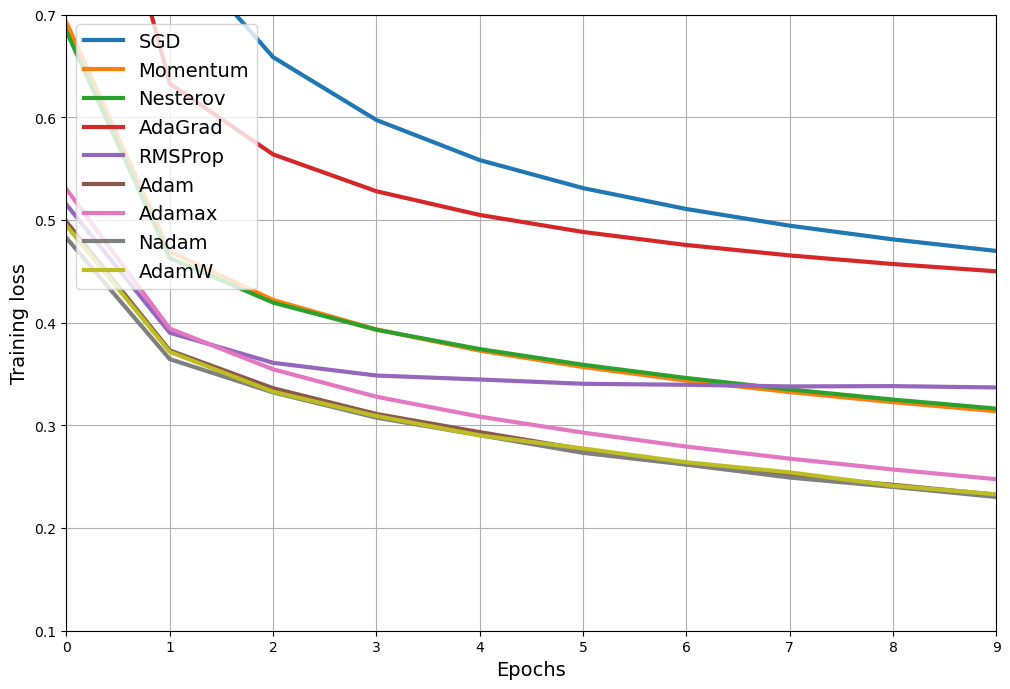

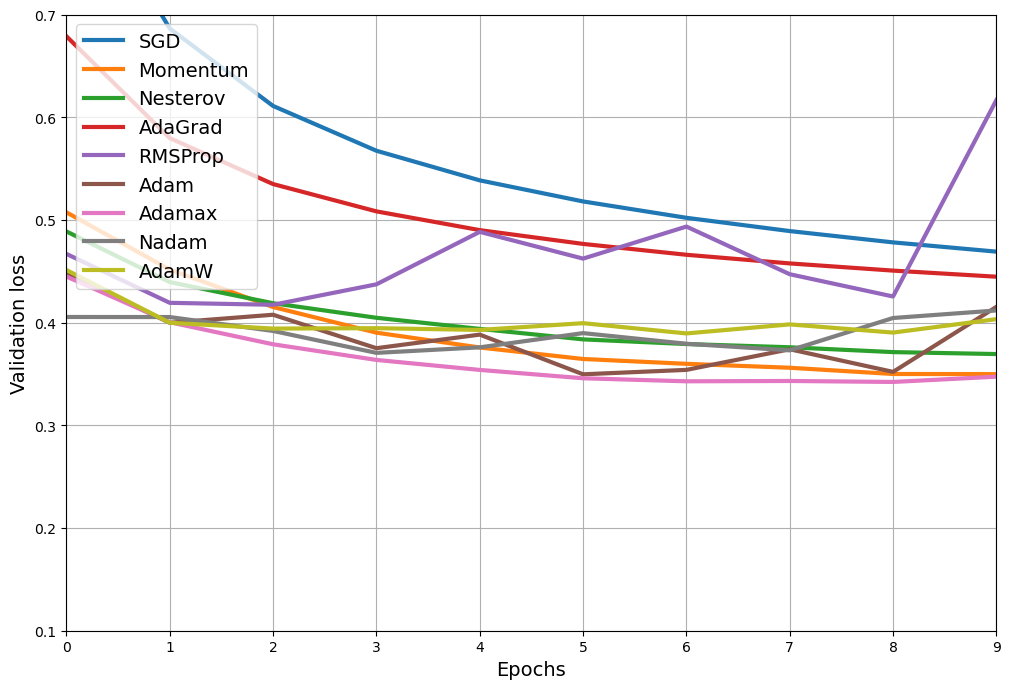

In [78]:
# extra code – visualize the learning curves of all the optimizers

for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip((history_sgd, history_momentum, history_nesterov,
                                  history_adagrad, history_rmsprop, history_adam,
                                  history_adamax, history_nadam, history_adamw),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0.1, 0.7])
    plt.show()

## Conclusion: Faster Optimizers

Standard Stochastic Gradient Descent (SGD) is often too slow for training deep neural networks and struggles with complex loss landscapes, such as narrow "ravines." To accelerate convergence and boost performance, researchers have developed **Faster Optimizers**. these are generally categorized into momentum-based methods, adaptive learning rate methods, and advanced hybrids.

### 1. Momentum-Based Optimizers
These algorithms simulate physical inertia to speed up training.

*   **Momentum Optimization:** Simulates a ball rolling down a slope. Unlike vanilla SGD which only considers the local gradient, momentum accumulates a "velocity" from past gradients. This allows it to accelerate through plateaus and dampen oscillations in steep valleys, often converging up to 10 times faster than SGD.
*   **Nesterov Accelerated Gradient (NAG):** A variant of momentum that calculates the gradient at a "look-ahead" position (slightly ahead in the direction of the momentum). This mechanism makes updates more precise and significantly reduces overshooting, making it almost always faster and more stable than standard momentum.

### 2. Adaptive Learning Rate Optimizers
These algorithms individually tune the learning rate for every parameter, which is highly effective for data with varying scales or sparsity.

*   **AdaGrad:** Scales the learning rate of each parameter based on the sum of past squared gradients. While useful for sparse data, its learning rate decays monotonically and often causes training to **stop prematurely** in deep networks.
*   **RMSProp:** Fixes AdaGrad's flaw by using an "exponentially decaying moving average" to accumulate recent squared gradients. It ensures the learning rate doesn't vanish and is a preferred choice for **Recurrent Neural Networks (RNNs)**.

### 3. Advanced and Hybrid Optimizers
The industry standards that combine momentum stability with adaptive scaling.

*   **Adam (Adaptive Moment Estimation):** Combines the ideas of both Momentum (tracking the mean of gradients) and RMSProp (tracking the variance). It is robust to hyperparameters and is the **top choice for rapid prototyping**.
*   **Nadam:** Incorporates the **Nesterov trick** into the Adam optimizer, typically resulting in even faster convergence than standard Adam.
*   **AdamW:** A crucial improvement that **decouples** weight decay from the gradient updates. It is the default optimizer for modern large-scale models (like **Transformers** and **LLaMA**) because it offers much stronger generalization capabilities.

---

### Practical Guidelines and Recommendations

*   **Initial Development:** Prioritize **Adam** or **Nadam** for their ease of use and exceptionally fast initial convergence.
*   **Peak Generalization:** If you have the resources for extensive hyperparameter tuning, **SGD with Momentum (and NAG)** paired with a well-designed **Learning Rate Schedule** (such as the **1cycle policy**) often finds better global optima than Adam.
*   **Large-Batch Training:** For distributed training with very large batches, consider specialized optimizers like **LARS** to maintain training stability.

This concludes our exploration of optimization algorithms—next, we will dive into advanced learning rate scheduling and other sophisticated training techniques!

---

## Learning Rate Scheduling
Learning-rate (LR) scheduling controls **how the step size changes during training** — a small, well-chosen schedule often speeds convergence and improves final generalization more than many other hyperparameter tweaks.

Practical overview
- Conceptual Refinement: The Learning Rate Trilemma
    - In deep learning, you face a trade-off:
        - High Learning Rate: Risks diverging or overshooting the global minimum.
        - Low Learning Rate: Takes too long to converge and may get stuck in poor local minima.
        - Decaying Learning Rate: Starts high to make rapid progress and decreases to "settle" into the minimum.generalization.  
- Common schedules:
    - Step decay — drop LR by a factor at fixed epochs (simple, robust).  
    - Exponential decay — smooth multiplicative decay.  
    - Cosine annealing (with/without restarts) — smooth decay that often yields better final results.  
    - One‑cycle / cyclical LR — helps escape sharp minima and speeds training.  
    - Warmup — ramp LR up for a few epochs/steps (essential for large‑batch training).  
    - ReduceLROnPlateau — lower LR when a monitored metric stops improving.
- Keras tools: `tf.keras.optimizers.schedules.*`, `tf.keras.callbacks.LearningRateScheduler`, `tf.keras.callbacks.ReduceLROnPlateau`.
    - **`tf.keras.optimizers.schedules.*`**: Optimizer schedules are stateless functions of the current step
    - **`tf.keras.callbacks.*`**: Callbacks can implement more complex logic based on training progress and metrics.
- Recipe:
    - Do a short LR sweep to find a good max LR.  
    - Prototype with `Adam` (lr ≈ 1e‑3); for best final results switch to `SGD`+momentum (lr ≈ 0.01–0.1) and use a decay (cosine or one‑cycle).  
    - Use 5–10% of total steps for warmup when training with large batches.  
    - Monitor validation metrics and save the best weights (early stopping + LR reduction).
- Typical defaults to try: `Adam` lr=1e‑3, `SGD`+momentum lr=0.01 (scale with batch size), final LR floor ≈ 1e‑6.

The cells that follow show concrete Keras examples and recipes (LR schedules, callbacks, and a one‑cycle implementation).

### Power Scheduling

Power scheduling decays the learning rate using a polynomial function, where the learning rate decreases as training progresses. The general formula is:
$$
\eta_t = \dfrac{\eta_0}{(1 + \text{decay\_rate} \cdot t / s)^{power}}
$$
where 
- Keras uses `power = 1`.
- `decay_rate` controls how quickly the learning rate decreases
- `s` is a scaling factor (decay steps often set to the total number of steps or epochs).
- `t` is the current step or epoch.

**Note**: Optimizers used to have a `decay` argument for this, but it was deprecated. The legacy method of passing a `decay` argument directly to an optimizer (e.g., `tf.keras.optimizers.Adam(learning_rate=0.001, decay=1e-6)`) is no longer recommended. You must use the schedulers in `tf.keras.optimizers.schedules` instead.

In [79]:
dir(tf.keras.optimizers.schedules) # extra code – list all learning rate schedules in tf.keras.optimizers.schedules

['CosineDecay',
 'CosineDecayRestarts',
 'ExponentialDecay',
 'InverseTimeDecay',
 'LearningRateSchedule',
 'PiecewiseConstantDecay',
 'PolynomialDecay',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'deserialize',
 'serialize']


In the following, we will use `tf.keras.optimizers.schedules.InverseTimeDecay` to implement power scheduling.

In [80]:
power_lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=1.0,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=power_lr_schedule)

The `InverseTimeDecay` scheduler calculates the learning rate $\eta_t$ at step $t$ using the following formula:

$$\eta_t = \frac{\eta_0}{1 + c \cdot \frac{t}{s}}$$

If you set `staircase=True`, Keras replaces the continuous ratio $t / s$ with its floor value $\lfloor t / s \rfloor$:

$$\eta_t = \frac{\eta_0}{1 + c \cdot \lfloor t / s \rfloor}$$

In this implementation, `InverseTimeDecay` effectively performs **power scheduling** with the power coefficient set to 1. Specifically:
*   $\eta_0$ represents the `initial_learning_rate`.
*   $c$ represents the `decay_rate`.
*   $s$ represents the `decay_steps` (the scaling factor).

In [81]:
history_power_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7649 - loss: 0.6878 - val_accuracy: 0.8262 - val_loss: 0.4961
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8353 - loss: 0.4711 - val_accuracy: 0.8396 - val_loss: 0.4534
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8505 - loss: 0.4269 - val_accuracy: 0.8462 - val_loss: 0.4308
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8589 - loss: 0.4016 - val_accuracy: 0.8488 - val_loss: 0.4177
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8648 - loss: 0.3840 - val_accuracy: 0.8542 - val_loss: 0.4060
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8685 - loss: 0.3707 - val_accuracy: 0.8584 - val_loss: 0.3953
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8723 - loss: 0.3599 - val_accuracy: 0.8590 - val_loss: 0.3884
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8749 - loss: 0.3510 - 

In [82]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np # Import numpy if not already present

# Calculate steps per epoch based on your training data and batch size
import math
batch_size = 32 # default used in model.fit if not specified
steps_per_epoch = math.ceil(len(X_train) / batch_size)

def plot_learning_rate_schedule(
    history: tf.keras.callbacks.History,
    lr_schedule_fn: callable,
    plot_label: str = "Learning rate",
    plot_title: str = "Learning Rate Schedule"
) -> None:
    """
    Visualizes a learning rate schedule from a Keras History object.

    Args:
        history: The Keras History object obtained from model.fit().
        lr_schedule_fn: The tf.keras.optimizers.schedules.LearningRateSchedule object
                        or a callable that takes a step (int) and returns the learning rate.
        plot_label: Label for the plotted line in the legend.
        plot_title: Title for the plot.
    """
    plt.figure(figsize=(12, 8))

    # Calculate learning rates for each epoch using the provided schedule function.
    # We cast the epoch number to a tf.int64 tensor as required by tf.keras.optimizers.schedules.
    learning_rates_at_epochs = [
        lr_schedule_fn(tf.constant(epoch, dtype=tf.int64)).numpy()
        for epoch in history.epoch
    ]

    # learning rate
    plt.plot(history.epoch, learning_rates_at_epochs, label=plot_label, linewidth=3)
    plt.grid(True)
    plt.xlabel("Epochs")
    plt.ylabel("Learning rate", color='b') # Modified to set color for primary y-axis
    plt.tick_params('y', colors='b') # Added for primary y-axis
    plt.legend()

    # validation loss
    ax2 = plt.gca().twinx()
    ax2.plot(history.epoch, history.history["val_loss"], "r^-", label="Validation Loss", linewidth=2)
    ax2.set_ylabel('Validation Loss', color='r')
    ax2.tick_params('y', colors='r')

    plt.title(plot_title)
    plt.legend(loc="lower left")
    plt.show()

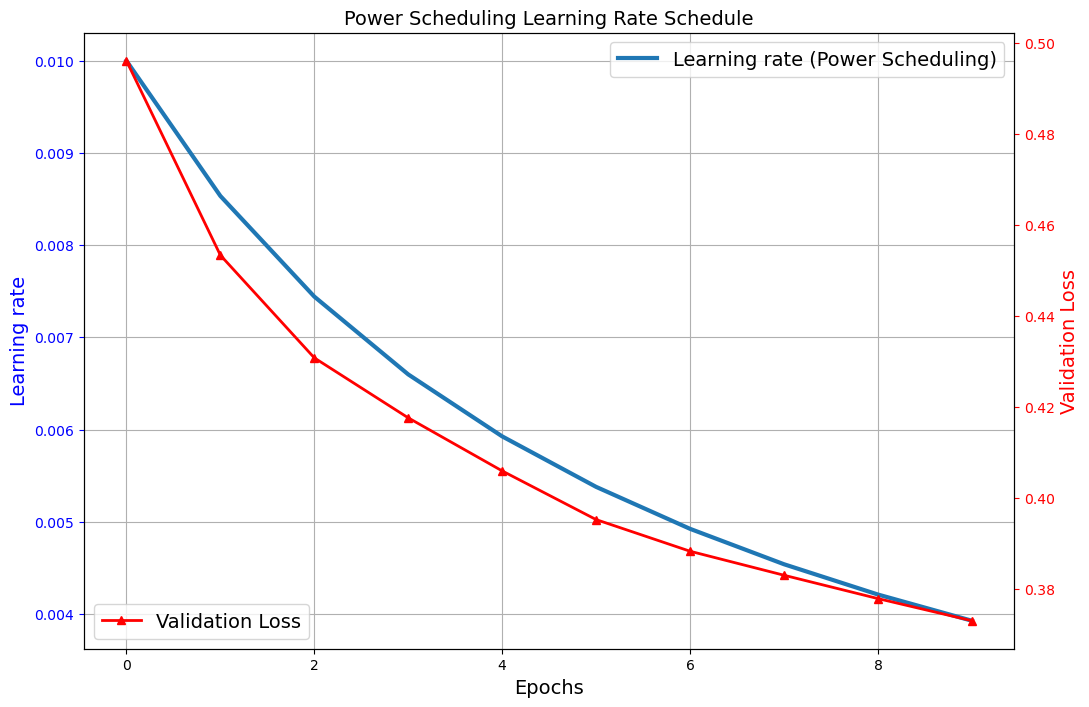

In [83]:
# visualize the learning rate schedule of the power scheduling optimizer

# We need to multiply the epoch number by steps_per_epoch to get the correct step count for the learning rate schedule, since the schedule is defined in terms of steps, not epochs.
plot_learning_rate_schedule(
    history=history_power_scheduling,
    lr_schedule_fn=lambda epoch: power_lr_schedule(epoch * steps_per_epoch),
    plot_label="Learning rate (Power Scheduling)",
    plot_title="Power Scheduling Learning Rate Schedule"
)

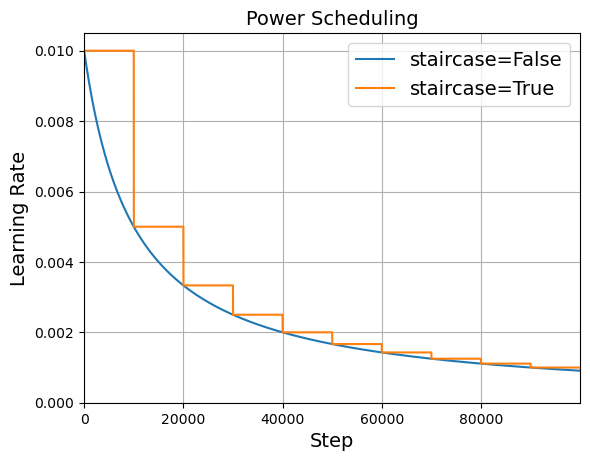

In [84]:
# extra code – this cell plots power scheduling with staircase=True or False

initial_learning_rate = 0.01
decay_rate = 1.0
decay_steps = 10_000

steps = np.arange(100_000)
lrs = initial_learning_rate / (1 + decay_rate * steps / decay_steps)
lrs2 = initial_learning_rate / (1 + decay_rate * np.floor(steps / decay_steps))

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis((0, steps.max(), 0, 0.0105))
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Power Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### Exponential Scheduling

$$
\eta_t = \eta_0 \cdot \text{decay\_rate}^{t / s}
$$
where
- `decay_rate` is the base of the exponential decay (e.g., 0.96).
- `s` is a scaling factor (decay steps often set to the total number of steps or epochs).
- `t` is the current step or epoch.

Next, the `ExponentialDecay` scheduler calculates the learning rate $\eta_t$ at step $t$ using the following formula:

$$\eta_t = \eta_0 \cdot \gamma^{t / s}$$

If you set `staircase=True`, Keras replaces the continuous ratio $t / s$ with its floor value $\lfloor t / s \rfloor$, resulting in a step-like decay:

$$\eta_t = \eta_0 \cdot \gamma^{\lfloor t / s \rfloor}$$

In this implementation:
*   $\eta_0$ corresponds to the `initial_learning_rate`.
*   $\gamma$ corresponds to the `decay_rate` (the base of the exponential).
*   $s$ corresponds to the `decay_steps` (the interval over which the decay is applied).

This ensures the learning rate is multiplied by the decay rate every $s$ steps, allowing for a smooth or discrete reduction in the step size as training progresses.

In [85]:
exponential_lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=exponential_lr_schedule)

In [86]:
history_exponential_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7655 - loss: 0.6739 - val_accuracy: 0.8272 - val_loss: 0.4906
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8359 - loss: 0.4682 - val_accuracy: 0.8350 - val_loss: 0.4552
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8497 - loss: 0.4260 - val_accuracy: 0.8414 - val_loss: 0.4340
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8580 - loss: 0.4024 - val_accuracy: 0.8448 - val_loss: 0.4169
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8641 - loss: 0.3863 - val_accuracy: 0.8502 - val_loss: 0.4049
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8691 - loss: 0.3744 - val_accuracy: 0.8552 - val_loss: 0.3966
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8722 - loss: 0.3652 - val_accuracy: 0.8586 - val_loss: 0.3886
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8746 - loss: 0.3582 - 

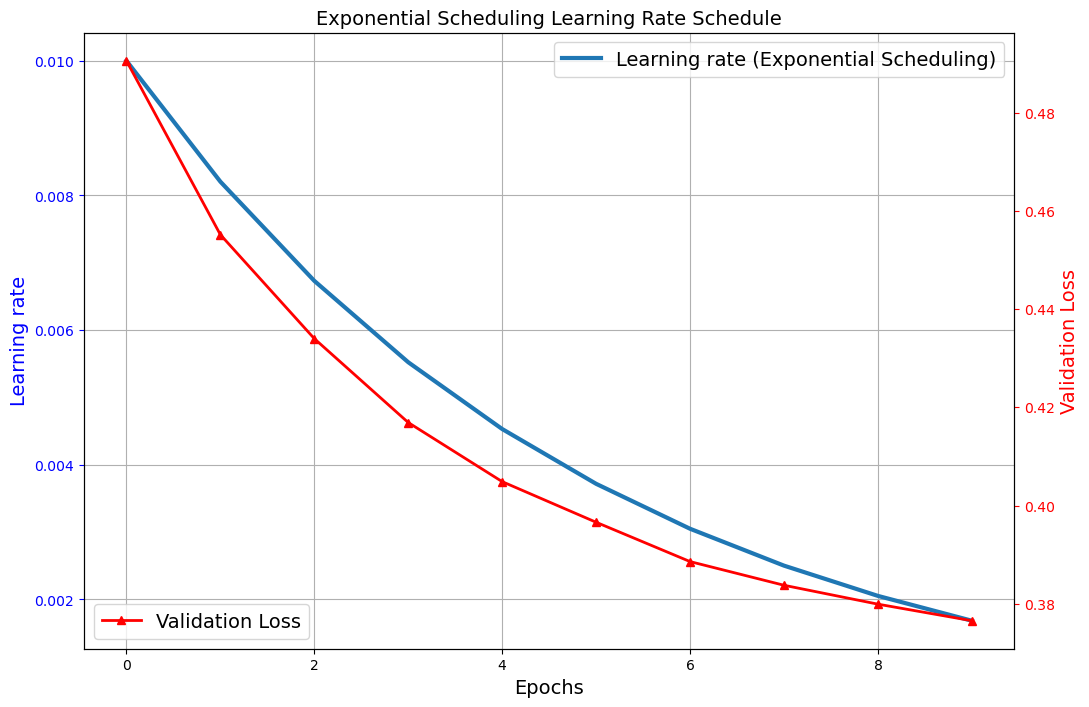

In [87]:
# visualize the learning rate schedule of the exponential scheduling optimizer
plot_learning_rate_schedule(
    history=history_exponential_scheduling,
    lr_schedule_fn=lambda epoch: exponential_lr_schedule(epoch * steps_per_epoch),
    plot_label="Learning rate (Exponential Scheduling)",
    plot_title="Exponential Scheduling Learning Rate Schedule"
)

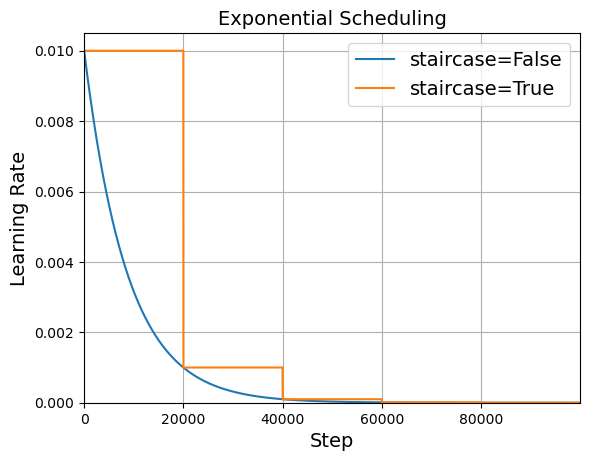

In [88]:
# extra code – this cell plots exponential scheduling

initial_learning_rate = 0.01
decay_rate = 0.1
decay_steps = 20_000

steps = np.arange(100_000)
lrs = initial_learning_rate * decay_rate ** (steps / decay_steps)
lrs2 = initial_learning_rate * decay_rate ** np.floor(steps / decay_steps)

plt.plot(steps, lrs,  "-", label="staircase=False")
plt.plot(steps, lrs2,  "-", label="staircase=True")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Exponential Scheduling", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

---
### Using LearningRateScheduler Callback
Keras also provides a `LearningRateScheduler` callback class that lets you define your own scheduling function. Let's see how you could use it to implement exponential decay. Note that in this case the learning rate only changes at each epoch, not at each step:

In [89]:
def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

In [90]:
def exponential_decay(lr0, s):
    """Returns a function that computes the exponential decay of the learning rate.
    Args:
        lr0: initial learning rate (float).
        s: decay speed (float). The larger `s` is, the slower the learning rate
           decreases."""
    def exponential_decay_fn(epoch):
        """Computes the exponential decay of the learning rate for a given epoch.
        Args:
            epoch: current epoch number (int).
        Returns:
            The exponentially decayed learning rate (float) for the given epoch.
        """
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.01, s=20)

Then, integrate a dynamic learning rate schedule using the `LearningRateScheduler` callback.
The LearningRateScheduler constructor accepts a callable, in this case `exponential_decay_fn`, which is expected to take the current epoch index as an input and return the desired learning rate. This callback is executed at the onset of each epoch within the `model.fit()` method. By including it in the callbacks list, the optimizer's learning rate is programmatically updated before the next set of weight updates begins.

In [91]:
# extra code – build and compile a model for Fashion MNIST

tf.random.set_seed(42)
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [92]:
n_epochs = 20

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7684 - loss: 0.6764 - val_accuracy: 0.8320 - val_loss: 0.4745 - learning_rate: 0.0100
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8368 - loss: 0.4656 - val_accuracy: 0.8478 - val_loss: 0.4314 - learning_rate: 0.0089
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8521 - loss: 0.4216 - val_accuracy: 0.8520 - val_loss: 0.4126 - learning_rate: 0.0079
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8605 - loss: 0.3954 - val_accuracy: 0.8518 - val_loss: 0.4047 - learning_rate: 0.0071
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8663 - loss: 0.3772 - val_accuracy: 0.8566 - val_loss: 0.3954 - learning_rate: 0.0063
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8712 - loss: 0.3635 - val_accuracy: 0.8590 - val_loss: 0.3889 - learning_rate: 0.0056
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8749 - l

Therefore, `tf.keras.callbacks.LearningRateScheduler` is a Keras callback that allows you to implement custom learning rate scheduling during training.

*   **Core Functionality**: It takes a single argument: a Python callable (a function) that determines the learning rate for a given epoch.
*   **Execution**: This function (e.g., `exponential_decay_fn`) is invoked at the beginning of each epoch, receiving the current epoch number as its sole argument. It then returns the new learning rate that the optimizer will use for that epoch.
*   **Flexibility**: This mechanism provides a flexible and programmatic way to implement various custom learning rate decay strategies, including:
    *   Exponential decay
    *   Step decay
    *   Polynomial decay
*   **Integration**: The created `lr_scheduler` object is passed to the `callbacks` argument of the `model.fit()` method to seamlessly apply the defined schedule throughout the training process.

In [93]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [43]:
# visualize the learning rate schedule of the exponential scheduling optimizer with the custom exponential decay function
def plot_lr_and_loss_from_history(history: tf.keras.callbacks.History, n_epochs: int, title: str = "Learning Rate and Validation Loss"):
    """
    Visualizes the learning rate schedule and validation loss from a Keras History object.

    This function plots the learning rate used at each epoch (retrieved from `history.history`)
    against the validation loss, allowing for easy comparison of their trends over time.

    Args:
        history (tf.keras.callbacks.History): The Keras History object obtained from `model.fit()`,
            which contains training metrics including 'learning_rate' or 'lr' and 'val_loss'.
        n_epochs (int): The total number of epochs for which the model was trained.
            Used for setting appropriate x-axis ticks.
        title (str, optional): The title to display above the plot. Defaults to
            "Learning Rate and Validation Loss".
    """
    plt.figure(figsize=(12, 8))

    # Try to retrieve learning rate from history, checking both 'learning_rate' and 'lr'
    learning_rates_data = history.history.get("learning_rate")
    if learning_rates_data is None:
        learning_rates_data = history.history.get("lr")

    if learning_rates_data:
        plt.plot(history.epoch, learning_rates_data, 'bo-', label="Learning Rate", linewidth=3)
        plt.ylabel("Learning Rate", color='b')
        plt.tick_params('y', colors='b')
        plt.legend(loc="upper right")
    else:
        print("Warning: Learning rate data ('learning_rate' or 'lr') not found in `history.history`.")
        plt.ylabel("Primary Y-axis (LR data missing)", color='b')
        plt.tick_params('y', colors='b')


    plt.xlabel("Epochs")
    plt.title(title)
    plt.xticks(range(0, n_epochs + 1, max(1, n_epochs // 10))) # Adjusted xticks for better display

    ax2 = plt.gca().twinx()
    ax2.plot(history.epoch, history.history["val_loss"], "r^-", label="Validation Loss", linewidth=2)
    ax2.set_ylabel('Validation Loss', color='r')
    ax2.tick_params('y', colors='r')
    ax2.legend(loc="lower left")

    plt.grid(True)
    plt.show()

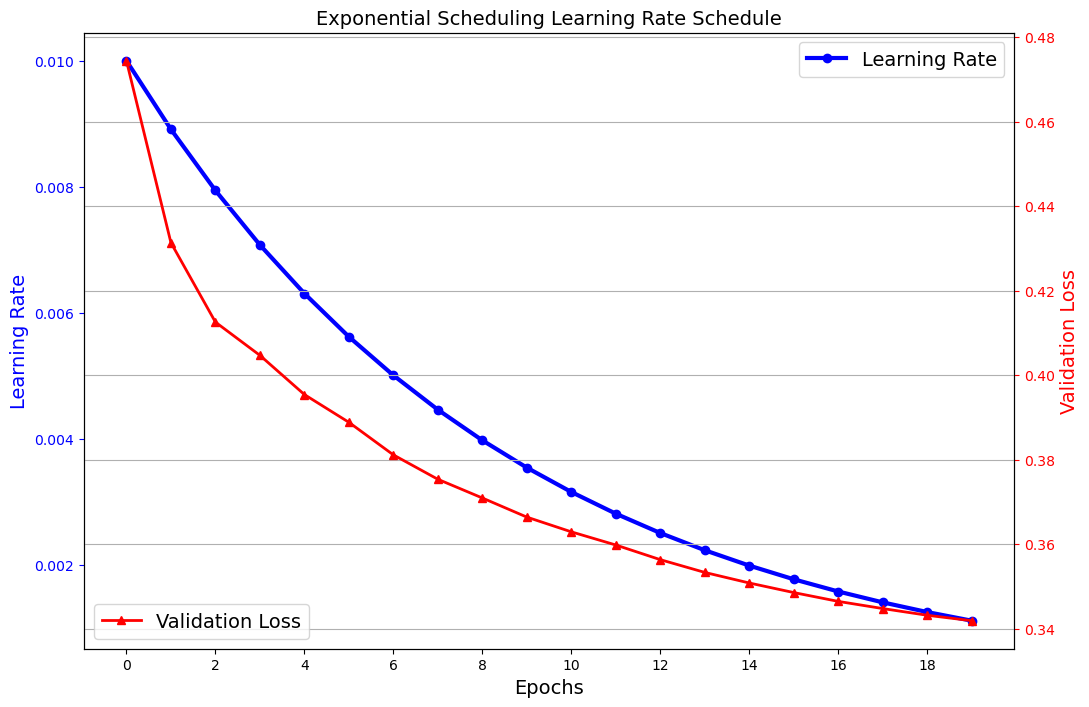

In [95]:

plot_lr_and_loss_from_history(history, n_epochs, title="Exponential Scheduling Learning Rate Schedule")

Alternatively, the schedule function can take the current learning rate as a second argument:

In [96]:
def exponential_decay_fn(epoch, lr):
    return lr * 0.1 ** (1 / 20)

**Extra material**: if you want to update the learning rate at each iteration rather than at each epoch, you can write a custom callback. Since the `batch` argument passed to `on_batch_begin()` is reset at each epoch, you should use the `self.model.optimizer.iterations` variable to track the total number of steps:

In [97]:
K = tf.keras.backend

class ExponentialDecay(tf.keras.callbacks.Callback):
    """Custom Keras callback to implement exponential learning rate decay per batch.

    This callback updates the learning rate at the beginning of each batch
    rather than at the beginning of each epoch.

    Args:
        n_steps (int): The number of steps over which the learning rate decays
            by a factor of 0.1.
    """
    def __init__(self, n_steps=40_000):
        super().__init__()
        self.n_steps = n_steps

    def on_batch_begin(self, batch, logs=None):
        # Note: the `batch` argument is reset at each epoch
        lr = self.model.optimizer.learning_rate.numpy()
        new_learning_rate = lr * 0.1 ** (1 / self.n_steps)
        self.model.optimizer.learning_rate = new_learning_rate

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = self.model.optimizer.learning_rate.numpy()

In [98]:
lr0 = 0.01
model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [99]:
import math

batch_size = 32
n_steps = n_epochs * math.ceil(len(X_train) / batch_size)
exp_decay = ExponentialDecay(n_steps)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[exp_decay])

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7610 - loss: 0.6950 - val_accuracy: 0.8290 - val_loss: 0.4893 - lr: 0.0089
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8333 - loss: 0.4753 - val_accuracy: 0.8366 - val_loss: 0.4497 - lr: 0.0079
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8494 - loss: 0.4283 - val_accuracy: 0.8452 - val_loss: 0.4265 - lr: 0.0071
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8585 - loss: 0.4001 - val_accuracy: 0.8526 - val_loss: 0.4074 - lr: 0.0063
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8649 - loss: 0.3803 - val_accuracy: 0.8570 - val_loss: 0.3941 - lr: 0.0056
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8700 - loss: 0.3655 - val_accuracy: 0.8592 - val_loss: 0.3839 - lr: 0.0050
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8739 - loss: 0.3540 - val_accuracy: 0.8644 - val_loss: 0.3755 - lr: 0.0045

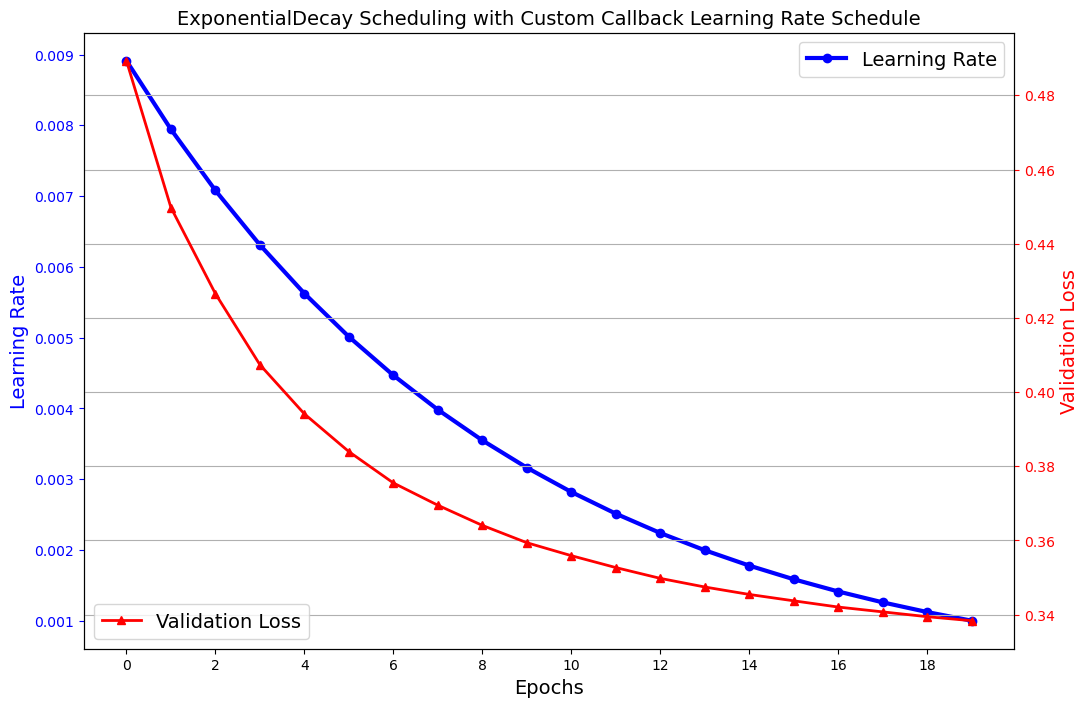

In [100]:
plot_lr_and_loss_from_history(history, n_epochs, title="ExponentialDecay Scheduling with Custom Callback Learning Rate Schedule")

In [101]:
# investigate the methods in tf.keras.callbacks.Callback
for method in dir(tf.keras.callbacks.Callback):
    if not method.startswith("_"):
        print(method)

model
on_batch_begin
on_batch_end
on_epoch_begin
on_epoch_end
on_predict_batch_begin
on_predict_batch_end
on_predict_begin
on_predict_end
on_test_batch_begin
on_test_batch_end
on_test_begin
on_test_end
on_train_batch_begin
on_train_batch_end
on_train_begin
on_train_end
set_model
set_params


---
### Piecewise Constant Scheduling

You manually define different learning rates for different phases of training (e.g., 0.1 for 5 epochs, then 0.01 for 10 epochs).

In [102]:
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[50_000, 80_000],
    values=[0.01, 0.005, 0.001]
)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

In this example, we will use `tf.keras.optimizers.schedules.PiecewiseConstantDecay` to implement piecewise constant scheduling, where the learning rate changes at specified boundaries.
- `boundaries` is a list of epoch indices where the learning rate changes.
- `values` is a list of learning rates corresponding to each interval defined by the boundaries.

In [103]:
history_piecewise_scheduling = build_and_train_model(optimizer)  # extra code

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7707 - loss: 0.6767 - val_accuracy: 0.8294 - val_loss: 0.4832
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8347 - loss: 0.4681 - val_accuracy: 0.8456 - val_loss: 0.4389
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8498 - loss: 0.4225 - val_accuracy: 0.8510 - val_loss: 0.4153
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8585 - loss: 0.3948 - val_accuracy: 0.8538 - val_loss: 0.3999
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8650 - loss: 0.3750 - val_accuracy: 0.8612 - val_loss: 0.3867
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8704 - loss: 0.3594 - val_accuracy: 0.8648 - val_loss: 0.3810
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8748 - loss: 0.3466 - val_accuracy: 0.8650 - val_loss: 0.3783
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8791 - loss: 0.3355 - 

In [104]:
print(steps_per_epoch)

1719


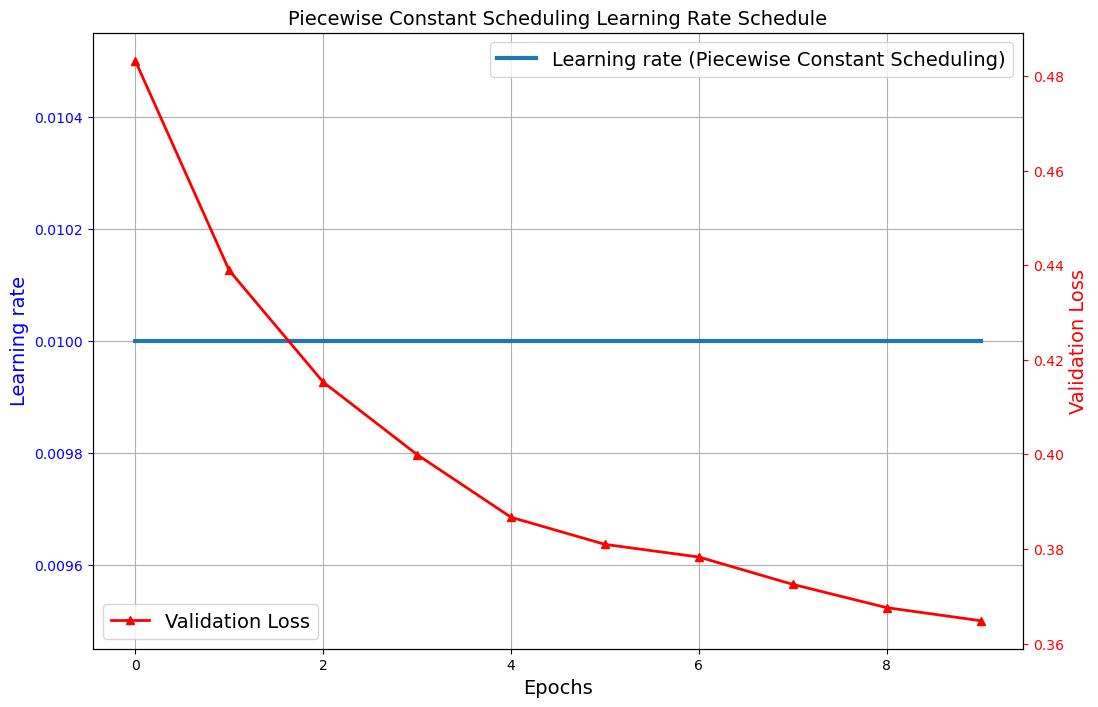

In [105]:
plot_learning_rate_schedule(
    history=history_piecewise_scheduling,
    lr_schedule_fn=lambda epoch: lr_schedule(epoch * steps_per_epoch),
    plot_label="Learning rate (Piecewise Constant Scheduling)",
    plot_title="Piecewise Constant Scheduling Learning Rate Schedule"
)

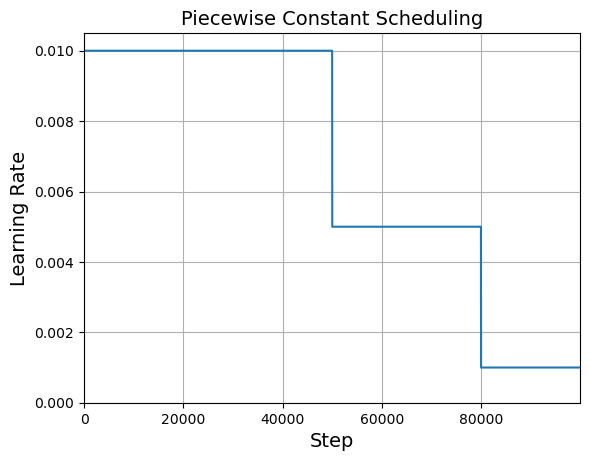

In [106]:
# extra code – this cell plots piecewise constant scheduling

boundaries = [50_000, 80_000]
values = [0.01, 0.005, 0.001]

steps = np.arange(100_000)

lrs = np.full(len(steps), values[0])
for boundary, value in zip(boundaries, values[1:]):
    lrs[boundary:] = value

plt.plot(steps, lrs, "-")
plt.axis([0, steps.max(), 0, 0.0105])
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Piecewise Constant Scheduling", fontsize=14)
plt.grid(True)
plt.show()

Just like we did with exponential scheduling, we could also implement piecewise constant scheduling manually:

In [107]:
def piecewise_constant_fn(epoch):
    if epoch < 5:
        return 0.01
    elif epoch < 15:
        return 0.005
    else:
        return 0.001

In [108]:
# extra code – this cell demonstrates a more general way to define
#              piecewise constant scheduling.

def piecewise_constant(boundaries, values):
    boundaries = np.array([0] + boundaries)
    values = np.array(values)
    def piecewise_constant_fn(epoch):
        return values[(boundaries > epoch).argmax() - 1]
    return piecewise_constant_fn

piecewise_constant_fn = piecewise_constant([5, 15], [0.01, 0.005, 0.001])

In [109]:
# extra code – use a tf.keras.callbacks.LearningRateScheduler like earlier

n_epochs = 25

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(piecewise_constant_fn)

model = build_model()
optimizer = tf.keras.optimizers.Nadam(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8077 - loss: 0.5410 - val_accuracy: 0.8174 - val_loss: 0.4736 - learning_rate: 0.0100
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8368 - loss: 0.4594 - val_accuracy: 0.8352 - val_loss: 0.4730 - learning_rate: 0.0100
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8458 - loss: 0.4366 - val_accuracy: 0.8204 - val_loss: 0.4626 - learning_rate: 0.0100
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8513 - loss: 0.4228 - val_accuracy: 0.8270 - val_loss: 0.4826 - learning_rate: 0.0100
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8544 - loss: 0.4170 - val_accuracy: 0.8402 - val_loss: 0.4527 - learning_rate: 0.0100
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8713 - loss: 0.3571 - val_accuracy: 0.8568 - val_loss: 0.3945 - learning_rate: 0.0050
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8735 - l

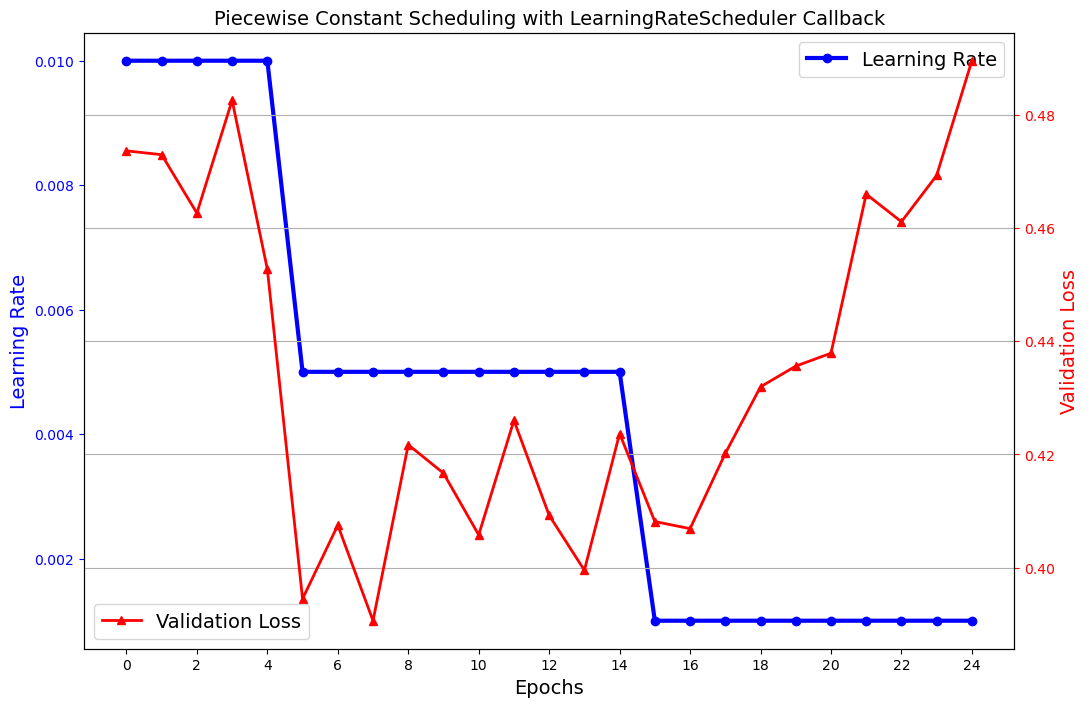

In [110]:
plot_lr_and_loss_from_history(history, n_epochs, title="Piecewise Constant Scheduling with LearningRateScheduler Callback")

We've looked at `InverseTimeDecay`, `ExponentialDecay`, and `PiecewiseConstantDecay`. A few more schedulers are available in `tf.keras.optimizers.schedules`, here is the full list:

In [111]:
for name in sorted(dir(tf.keras.optimizers.schedules)):
    if name[0] == name[0].lower():  # must start with capital letter
        continue
    scheduler_class = getattr(tf.keras.optimizers.schedules, name)
    print(f"• {name} – {scheduler_class.__doc__.splitlines()[0]}")

• CosineDecay – A `LearningRateSchedule` that uses a cosine decay with optional warmup.
• CosineDecayRestarts – A `LearningRateSchedule` that uses a cosine decay schedule with restarts.
• ExponentialDecay – A `LearningRateSchedule` that uses an exponential decay schedule.
• InverseTimeDecay – A `LearningRateSchedule` that uses an inverse time decay schedule.
• LearningRateSchedule – The learning rate schedule base class.
• PiecewiseConstantDecay – A `LearningRateSchedule` that uses a piecewise constant decay schedule.
• PolynomialDecay – A `LearningRateSchedule` that uses a polynomial decay schedule.


---

### Performance Scheduling (ReduceLROnPlateau)

Performance scheduling adjusts the learning rate based on the model's performance metrics, such as validation loss or accuracy. Unlike time-based schedules, it dynamically reduces the learning rate when a monitored metric stops improving, helping to fine-tune convergence and prevent overfitting. This is particularly useful for adaptive training where the optimal learning rate changes over time.

In [112]:
# extra code – build and compile the model

model = build_model()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])


In Keras, this is implemented using the `ReduceLROnPlateau` callback, which monitors a metric (e.g., validation loss) and reduces the learning rate by a factor when the metric hasn't improved for a specified number of epochs (patience). It can also stop training early if desired.

Key parameters:
- `monitor`: The metric to monitor (e.g., 'val_loss').
- `factor`: Factor by which the learning rate will be reduced (e.g., 0.5).
- `patience`: Number of epochs with no improvement after which learning rate will be reduced.
- `min_lr`: Minimum learning rate.
- `mode`: 'auto', 'min', or 'max' depending on whether the metric should be minimized or maximized.

This approach is robust for datasets where the optimal learning rate isn't known in advance and can lead to better generalization by allowing the model to settle into a minimum more gradually. Always combine with early stopping for efficiency.



In [113]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
history = model.fit(X_train, y_train, epochs=n_epochs,
                    validation_data=(X_valid, y_valid),
                    callbacks=[lr_scheduler])

Epoch 1/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7554 - loss: 0.7100 - val_accuracy: 0.8256 - val_loss: 0.4989 - learning_rate: 0.0100
Epoch 2/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8331 - loss: 0.4754 - val_accuracy: 0.8396 - val_loss: 0.4570 - learning_rate: 0.0100
Epoch 3/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8493 - loss: 0.4288 - val_accuracy: 0.8466 - val_loss: 0.4319 - learning_rate: 0.0100
Epoch 4/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8590 - loss: 0.3992 - val_accuracy: 0.8526 - val_loss: 0.4169 - learning_rate: 0.0100
Epoch 5/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8652 - loss: 0.3772 - val_accuracy: 0.8578 - val_loss: 0.4033 - learning_rate: 0.0100
Epoch 6/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8711 - loss: 0.3597 - val_accuracy: 0.8608 - val_loss: 0.3925 - learning_rate: 0.0100
Epoch 7/25
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8759 - l

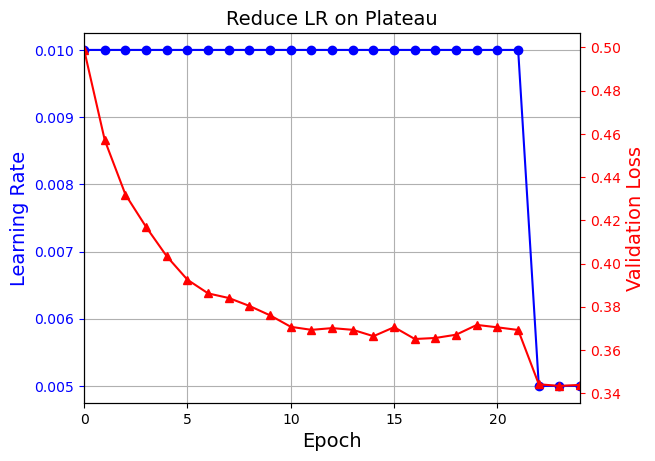

In [114]:
# extra code – this cell plots performance scheduling

plt.plot(history.epoch, history.history["learning_rate"], "bo-")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate", color='b')
plt.tick_params('y', colors='b')
plt.gca().set_xlim(0, n_epochs - 1)
plt.grid(True)

ax2 = plt.gca().twinx()
ax2.plot(history.epoch, history.history["val_loss"], "r^-")
ax2.set_ylabel('Validation Loss', color='r')
ax2.tick_params('y', colors='r')

plt.title("Reduce LR on Plateau", fontsize=14)
plt.show()

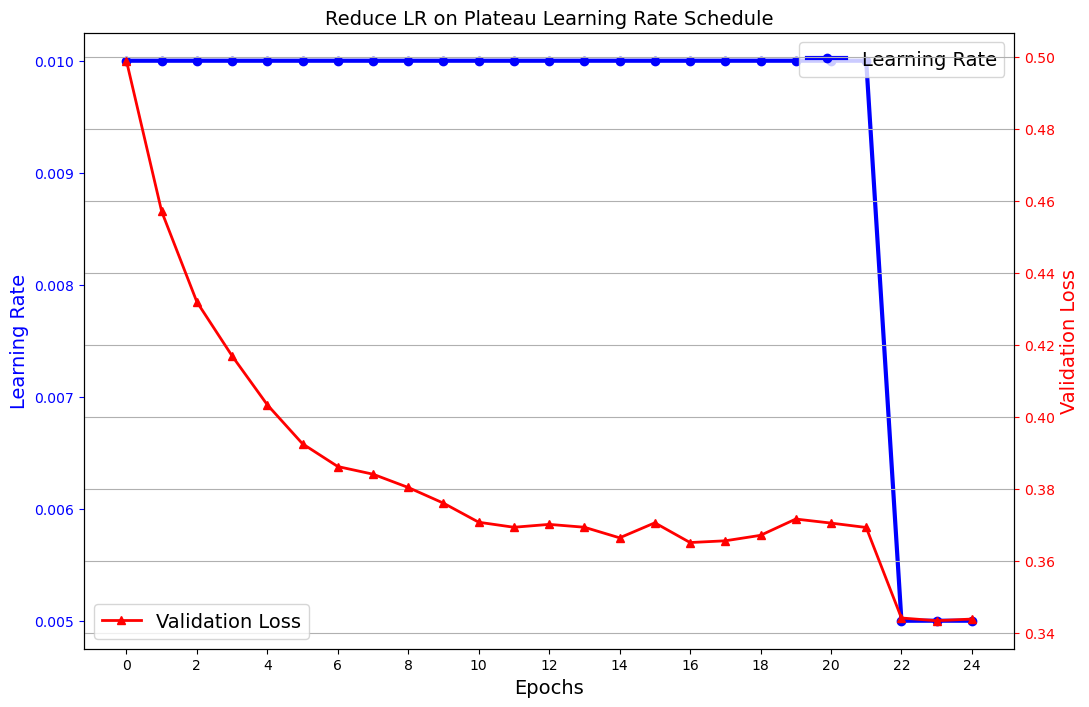

In [115]:
plot_lr_and_loss_from_history(history, n_epochs, title="Reduce LR on Plateau Learning Rate Schedule")

This figure visualizes the effects of a **`ReduceLROnPlateau` learning rate schedule** during model training, correlating the learning rate (blue line) with the validation loss (red line) over epochs.

#### Key Insights:

1.  **Initial Learning and Plateau (Epochs 0-15):**
    *   The learning rate starts at $0.01$ and remains constant for the first 15 epochs.
    *   During this phase, the validation loss decreases significantly from approximately $0.48$ to around $0.375$, indicating that the model is learning effectively.
    *   Around epoch 10-15, the validation loss starts to flatten out, suggesting that the model's progress has slowed with the current learning rate.

2.  **First Learning Rate Reduction (Epoch 15):**
    *   At epoch 15, the `ReduceLROnPlateau` callback detects that the validation loss has stopped improving (or improved insufficiently for a specified `patience` period).
    *   Consequently, the learning rate is sharply reduced from $0.01$ to $0.005$ (a factor of $0.5$).
    *   This reduction reinvigorates training, as the validation loss continues to drop further, reaching a new low of approximately $0.35$ around epoch 16-17.

3.  **Second Plateau and Reduction (Epochs 16-21):**
    *   After the first reduction, the learning rate remains constant at $0.005$.
    *   From epoch 16 to 21, the validation loss again stabilizes and shows minimal improvement, hovering around $0.35$.
    *   This signals another plateau, and the `ReduceLROnPlateau` callback prepares for a second adjustment.

4.  **Second Learning Rate Reduction (Epoch 21-22):**
    *   Between epoch 21 and 22, the learning rate is again halved, dropping from $0.005$ to $0.0025$.
    *   This second reduction proves beneficial, as the validation loss experiences another clear drop, reaching its lowest point in the plot at approximately $0.33$.

5.  **Final Convergence (Epochs 22-24):**
    *   With the learning rate at $0.0025$, the validation loss stabilizes at its minimum observed value, indicating good convergence with the adjusted learning rate.

#### Conclusion:

The `ReduceLROnPlateau` callback effectively manages the learning rate, dynamically adjusting it downwards when the model's performance on the validation set plateaus. Each reduction successfully helps the model escape local plateaus and achieve lower validation loss, leading to better overall convergence. This demonstrates the power of adaptive learning rate scheduling in fine-tuning model training and improving generalization.

---

### 1Cycle scheduling

The `ExponentialLearningRate` custom callback updates the learning rate during training, at the end of each batch. It multiplies it by a constant `factor`. It also saves the learning rate and loss at each batch. Since `logs["loss"]` is actually the mean loss since the start of the epoch, and we want to save the batch loss instead, we must compute the mean times the number of batches since the beginning of the epoch to get the total loss so far, then we subtract the total loss at the previous batch to get the current batch's loss.

#### 1. Finding the Optimal `max_lr` (find_learning_rate and plot_lr_vs_loss)

Before applying 1Cycle scheduling, it's common practice to perform a "learning rate range test" to identify an optimal `max_lr`.

##### `ExponentialLearningRate` Callback

This custom Keras callback is designed specifically for the LR range test:
*   In its `on_batch_end` method, it records the current learning rate and the batch loss.
*   It then exponentially increases the learning rate for the next batch.
*   By continuously increasing the LR, it helps identify the "sweet spot" where the loss starts to drop rapidly but hasn't yet exploded.

In [36]:
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    """A callback that exponentially increases the learning rate at each batch.

    Attributes:
        factor: The factor by which the learning rate is multiplied at each batch.
        rates: A list of learning rates recorded at each batch.
        losses: A list of losses recorded at each batch.
    """
    def __init__(self, factor):
        self.factor = factor # the factor by which the learning rate is multiplied at each batch
        self.rates = []
        self.losses = []

    def on_epoch_begin(self, epoch, logs=None):
        """ Resets the sum of epoch losses at the beginning of each epoch."""
        self.sum_of_epoch_losses = 0

    def on_batch_end(self, batch, logs=None):
        """ Updates the learning rate exponentially and records the learning rate and batch loss."""
        # Calculate the batch loss from the mean epoch loss and the sum of epoch losses so far
        mean_epoch_loss = logs["loss"]  # the epoch's mean loss so far 
        new_sum_of_epoch_losses = mean_epoch_loss * (batch + 1)
        batch_loss = new_sum_of_epoch_losses - self.sum_of_epoch_losses
        self.sum_of_epoch_losses = new_sum_of_epoch_losses

        # Get the current learning rate, record it along with the batch loss
        lr = self.model.optimizer.learning_rate.numpy()
        self.rates.append(lr)
        self.losses.append(batch_loss)

        # Update the learning rate by multiplying it with the factor.
        self.model.optimizer.learning_rate = lr * self.factor

In the context of Keras callbacks like `ExponentialLearningRate`, the `logs` parameter is a dictionary that contains various metrics and information available at the specific point in the training process when the callback method is invoked.

Here's a breakdown of what `logs` typically contains and its usage in the provided code:

1.  **What `logs` is:**
    *   It's a dictionary passed by the Keras training loop to callback methods such as `on_epoch_begin`, `on_epoch_end`, `on_batch_begin`, and `on_batch_end`.
    *   The contents of this dictionary vary slightly depending on which method is called.

2.  **Contents of `logs` (common examples):**
    *   **For `on_batch_end` (as seen in your code):**
        *   `logs["loss"]`: The current mean training loss for the epoch up to that batch. This is a running average.
        *   `logs["accuracy"]` (if applicable): The current mean training accuracy for the epoch up to that batch.
        *   Other metrics configured in `model.compile()`, such as `val_loss`, `val_accuracy`, etc., are typically present in `on_epoch_end` after validation has run.
    *   **For `on_epoch_end`:**
        *   `logs["loss"]`: The average training loss for the entire epoch.
        *   `logs["accuracy"]` (if applicable): The average training accuracy for the entire epoch.
        *   `logs["val_loss"]`: The validation loss for the entire epoch.
        *   `logs["val_accuracy"]` (if applicable): The validation accuracy for the entire epoch.

3.  **Usage in `ExponentialLearningRate`'s `on_batch_end` method:**
    *   `mean_epoch_loss = logs["loss"]`: Here, the callback accesses the `loss` key from the `logs` dictionary. This `logs["loss"]` value represents the *mean loss of the current epoch up to the current batch*.
    *   The code then uses this `mean_epoch_loss` along with the current `batch` number to calculate the `batch_loss` (the loss for the specific batch that just finished), which is then recorded in `self.losses`.

In summary, `logs` serves as a vital communication channel from the Keras training system to your custom callbacks, providing real-time data about the model's performance and state, which you can then use to implement custom logic.


##### `find_learning_rate(model, X, y, ...)` Function

This function orchestrates the LR range test:
*   It temporarily saves the model's initial weights and the optimizer's initial learning rate (`init_weights`, `init_lr`).
*   It calculates a factor to exponentially increase the learning rate from `min_rate` to `max_rate` over the specified number of iterations.
*   It sets the optimizer's learning rate to `min_rate`.
*   It trains the model for a short period (e.g., 1 epoch) using the `ExponentialLearningRate` callback.
*   Crucially, after the test, it resets the model's weights and the optimizer's learning rate to their initial states to avoid polluting the actual training run.
*   It returns the recorded rates and losses.
This process allows you to empirically determine a suitable `max_lr` for the 1Cycle policy, which can significantly enhance training speed and convergence.

In [34]:
import math
K = tf.keras.backend

def find_learning_rate(model, X, y, epochs=1, batch_size=32, min_rate=1e-4,
                       max_rate=1):
    """Finds the optimal learning rate by exponentially increasing it and recording the loss.

    This function trains the model for a specified number of epochs and batch size,
    while exponentially increasing the learning rate from `min_rate` to `max_rate`.
    It records the learning rates and corresponding losses at each batch, which can
    be used to analyze the relationship between learning rate and loss.

    Args:
        model: The Keras model to train.
        X: Training features.
        y: Training labels.
        epochs: Number of epochs to train for the LR search. Defaults to 1.
        batch_size: Batch size for training. Defaults to 32.
        min_rate: The minimum learning rate to start the search. Defaults to 1e-4.
        max_rate: The maximum learning rate to end the search. Defaults to 1.

    Returns:
        A tuple containing:
            - rates (list): A list of learning rates used at each batch.
            - losses (list): A list of losses recorded at each batch.
    """
    # Store the initial weights and learning rate
    init_weights = model.get_weights()
    init_lr = K.get_value(model.optimizer.learning_rate)
    
    # Calculate the total number of iterations (batches) for the given number of epochs and batch size
    iterations = math.ceil(len(X) / batch_size) * epochs
    
    # Calculate the factor to exponentially increase the learning rate from min_rate to max_rate over the total number of iterations
    factor = (max_rate / min_rate) ** (1 / iterations)
    model.optimizer.learning_rate = min_rate
    exp_lr = ExponentialLearningRate(factor)
    
    # Train the model for the specified number of epochs and batch size, using the ExponentialLearningRate callback to record learning rates and losses at each batch.
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size,
                        callbacks=[exp_lr])
    
    # Restore the model's initial weights and learning rate to ensure that this function does not affect subsequent training.
    model.optimizer.learning_rate = init_lr
    model.set_weights(init_weights)
    
    # Return the recorded learning rates and losses for each batch, which can be used to analyze the relationship between learning rate and loss.
    return exp_lr.rates, exp_lr.losses


##### `plot_lr_vs_loss(rates, losses)` Function

This function visualizes the results of the LR range test:
*   It plots the learning rate (on a logarithmic scale) against the corresponding loss.
*   The idea is to pick a `max_lr` that is slightly before the point where the loss starts to sharply increase, but after a point where the loss is clearly decreasing.
*   The provided code output suggests `0.1` as a good `max_lr`.

In [21]:
def plot_lr_vs_loss(rates, losses):
    """Plots the learning rates against the corresponding losses on a logarithmic scale."""
    plt.plot(rates, losses, "b")
    plt.gca().set_xscale('log')
    max_loss = losses[0] + min(losses)
    plt.hlines(min(losses), min(rates), max(rates), color="k")
    plt.axis((min(rates), max(rates), 0, max_loss))
    plt.xlabel("Learning rate")
    plt.ylabel("Loss")
    plt.grid()

Let's build a simple Fashion MNIST model and compile it:

In [119]:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

Now let's find the optimal max learning rate for 1cycle:

430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3893 - loss: 1.7879


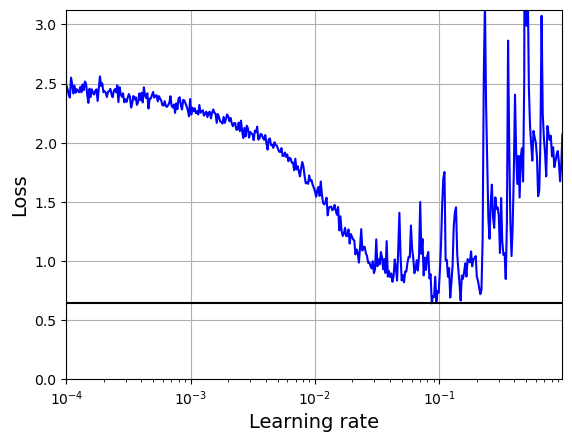

In [120]:
batch_size = 128
rates, losses = find_learning_rate(model, X_train, y_train, epochs=1,
                                   batch_size=batch_size)
plot_lr_vs_loss(rates, losses)

Looks like the max learning rate to use for 1cycle is around 10<sup>–1</sup>.

The `OneCycleScheduler` custom callback updates the learning rate at the beginning of each batch. It applies the logic described in the book: increase the learning rate linearly during about half of training, then reduce it linearly back to the initial learning rate, and lastly reduce it down to close to zero linearly for the very last part of training.

#### 2. The `OneCycleScheduler` Custom Callback

This is the core of the 1Cycle implementation. It's a `tf.keras.callbacks.Callback` that dynamically adjusts the learning rate at the end of each batch.

##### `__init__(self, iterations, max_lr, ...)`:

*   Initializes the scheduler with key hyperparameters: `iterations` (total number of batches for training), `max_lr`, `start_lr` (initial LR, typically `max_lr / 10`), `last_iterations` (number of batches for the final steep drop), and `last_lr` (final LR).
*   Calculates `half_iteration`, which determines the split point for the initial increase and subsequent decrease phases.

##### `_interpolate(self, iter1, iter2, lr1, lr2)`:

*   A helper method that performs linear interpolation. It calculates the learning rate at the current `self.iteration` based on two reference iterations (`iter1`, `iter2`) and their corresponding learning rates (`lr1`, `lr2`).

##### `on_batch_begin(self, batch, logs=None)`:

*   This method is called at the beginning of every training batch.
*   It checks `self.iteration` to determine which phase of the 1Cycle policy the training is currently in (increase, decrease, or final drop).
*   It uses `_interpolate` to calculate the appropriate `lr` for the current batch.
*   It then directly updates `self.model.optimizer.learning_rate = lr`, ensuring the learning rate is set correctly before the gradient update for the current batch.
*   `self.iteration` is incremented to track the global step count.

##### `on_epoch_end(self, epoch, logs=None)`:

*   This method is called at the end of each epoch.
*   It logs the current learning rate (which is the rate at the last batch of the epoch) into the `logs` dictionary, making it available in the `history.history` object for plotting.

In [40]:
from typing import Any, Dict, Optional

class OneCycleScheduler(tf.keras.callbacks.Callback):
    """A Keras callback that implements the 1Cycle learning rate scheduling.

    It increases the learning rate linearly from a starting value to a maximum
    value during the first half of training, then decreases it linearly back
    to the starting value, and finally reduces it linearly to a very low
    value for the final iterations.

    Args:
        iterations (int): Total number of training steps (batches).
        max_lr (float): The maximum learning rate reached.
        start_lr (float, optional): The initial learning rate. Defaults to
            `max_lr / 10`.
        last_iterations (int, optional): The number of steps for the final
            cooldown phase. Defaults to `iterations // 10 + 1`.
        last_lr (float, optional): The final learning rate at the end of
            training. Defaults to `start_lr / 1000`.
    """
    def __init__(self, 
                 iterations: int, 
                 max_lr: float = 1e-3, 
                 start_lr: float | None = None,
                 last_iterations: int | None = None, 
                 last_lr: float | None = None) -> None:
        """
        Initializes the scheduler.

        Args:
            iterations: Total training steps.
            max_lr: Peak learning rate reached.
            start_lr: Initial learning rate (defaults to max_lr / 10).
            last_iterations: Steps for the final cooldown phase.
            last_lr: Final learning rate at training end.
        """
        super().__init__()
        self.iterations = iterations
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_lr = last_lr or self.start_lr / 1000
        self.iteration = 0

    def _interpolate(self, iter1: int, iter2: int, lr1: float, lr2: float) -> float:
        """Linear interpolation between two learning rates."""
        return (lr2 - lr1) * (self.iteration - iter1) / (iter2 - iter1) + lr1

    def on_batch_begin(self, batch: int, logs: dict | None = None) -> None:
        """Updates the learning rate at the start of every batch."""
        if self.iteration < self.half_iteration:
            lr = self._interpolate(0, self.half_iteration, self.start_lr, self.max_lr)
        elif self.iteration < 2 * self.half_iteration:
            lr = self._interpolate(self.half_iteration, 2 * self.half_iteration, self.max_lr, self.start_lr)
        else:
            lr = self._interpolate(2 * self.half_iteration, self.iterations, self.start_lr, self.last_lr)
        
        self.iteration += 1
        self.model.optimizer.learning_rate = lr
        
    def on_epoch_end(self, epoch: int, logs: dict | None = None) -> None:
        logs = logs or {}
        logs['lr'] = self.model.optimizer.learning_rate.numpy()

#### Core Concept of 1Cycle Scheduling

The 1Cycle policy, proposed by Leslie N. Smith, involves cyclically varying the learning rate between a minimum and a maximum value. Typically, it consists of three main phases:

*   **Linear Increase**: The learning rate is gradually increased from a very low value (`start_lr`) to a relatively high value (`max_lr`) over the first $\approx 30-50\%$ of training iterations. This initial warm-up helps the model quickly traverse flatter regions of the loss landscape.
*   **Linear Decrease**: The learning rate is then linearly decreased from `max_lr` back to `start_lr` over the next $\approx 50-70\%$ of training. This helps the model settle into a good minimum.
*   **Final Steep Drop (Optional but common)**: For the very last few iterations, the learning rate is dropped significantly (e.g., to `start_lr / 1000`) to fine-tune the weights in the found minimum.


Let's build and compile a simple Fashion MNIST model, then train it using the `OneCycleScheduler` callback:

In [122]:
model = build_model()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"])
n_epochs = 25
onecycle = OneCycleScheduler(math.ceil(len(X_train) / batch_size) * n_epochs,
                             max_lr=0.1)
history = model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid, y_valid),
                    callbacks=[onecycle])

Epoch 1/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6719 - loss: 0.9953 - val_accuracy: 0.7910 - val_loss: 0.6150 - lr: 0.0180
Epoch 2/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7985 - loss: 0.5759 - val_accuracy: 0.8242 - val_loss: 0.5061 - lr: 0.0260
Epoch 3/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8246 - loss: 0.4966 - val_accuracy: 0.8324 - val_loss: 0.4780 - lr: 0.0340
Epoch 4/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8382 - loss: 0.4533 - val_accuracy: 0.8370 - val_loss: 0.4532 - lr: 0.0420
Epoch 5/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8481 - loss: 0.4234 - val_accuracy: 0.8414 - val_loss: 0.4429 - lr: 0.0500
Epoch 6/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8552 - loss: 0.4003 - val_accuracy: 0.8426 - val_loss: 0.4391 - lr: 0.0580
Epoch 7/25
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8608 - loss: 0.3825 - val_accuracy: 0.8432 - val_loss: 0.4384 - lr: 0.0660
Epoch 8/25
43

#### 3. Training with `OneCycleScheduler`

The final part combines all these elements:

*   A model is built and compiled, typically using an `SGD` optimizer. The initial learning rate for the optimizer itself might not be explicitly set, as the `OneCycleScheduler` will manage it dynamically.
*   `n_iterations` is calculated, representing the total number of batches across all epochs for the entire training run.
*   An instance of `OneCycleScheduler` is created, passing the calculated `n_iterations` and the chosen `max_lr` (e.g., `0.05`, typically determined from the LR range test).
*   The `model.fit()` method is called with `callbacks=[onecycle]`, ensuring that the `on_batch_begin` method of `OneCycleScheduler` is invoked before every batch, dynamically updating the learning rate.

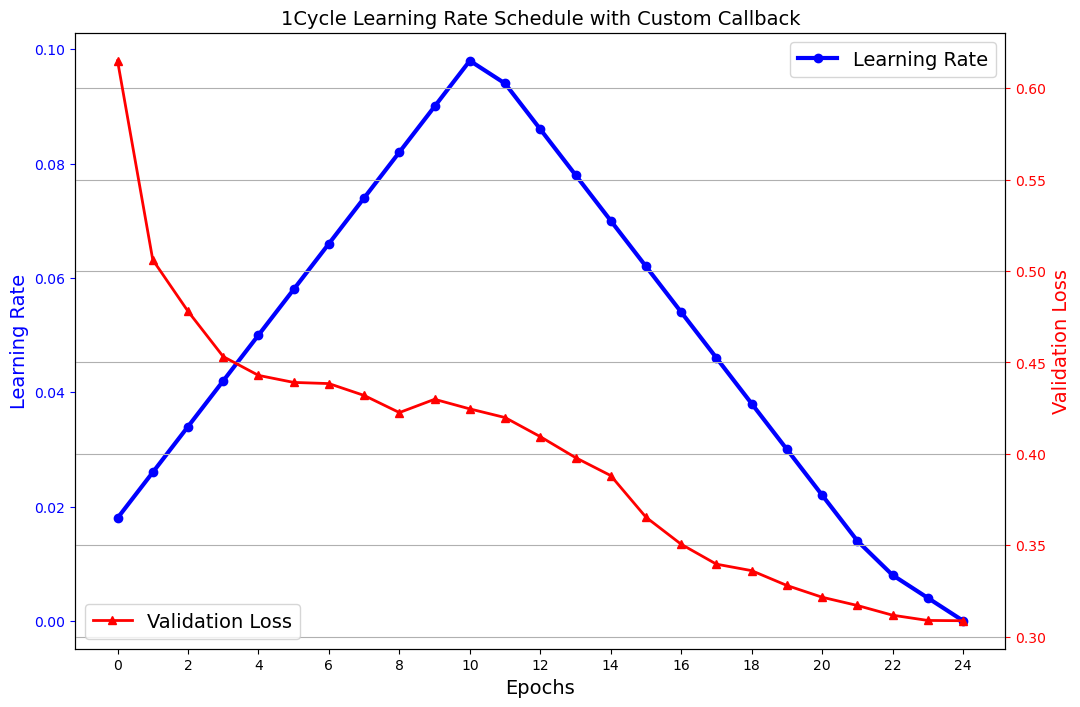

In [123]:
plot_lr_and_loss_from_history(history, n_epochs, title="1Cycle Learning Rate Schedule with Custom Callback")

The 1Cycle policy is an advanced technique that often leads to "super-convergence."
- Phase 1: Increase LR linearly from a low value to a very high max_lr (about half the training time).
- Phase 2: Decrease LR linearly back to the starting value.
- Phase 3: Drop LR close to zero for the final few iterations.

**Why it works**: The high learning rate in the middle acts as a regularizer, helping the model find flatter, more stable minima that generalize better.

#### Why 1Cycle Works and its Benefits

The 1Cycle policy is an advanced training strategy that often leads to "super-convergence," characterized by faster training and improved generalization. Here's why it's effective:

*   **Faster Convergence ("Super-convergence"):** The initial phase, where learning rates gradually increase, enables the optimizer to aggressively explore the loss landscape. This helps in quickly escaping saddle points or poor local minima and allows for larger steps during the middle of training, significantly accelerating convergence.

*   **Better Generalization:** High learning rates during training act as a form of implicit regularization. They prevent the model from settling into sharp, sub-optimal minima and encourage it to find flatter minima. Flatter minima often correlate with better generalization to unseen data, leading to more robust models.

*   **Reduced Hyperparameter Tuning:** The 1Cycle policy simplifies the learning rate tuning process. Instead of meticulously tuning a fixed learning rate or a complex decay schedule, it primarily requires tuning only the `max_lr` (and `start_lr` if not using the default).

*   **Implicit Regularization:** The cyclical nature of the learning rate provides an inherent regularization effect. By constantly varying the learning rate, it implicitly pushes the model out of purely static parameter configurations, similar to other regularization techniques like weight decay.

In the provided example, the 1Cycle policy demonstrates its effectiveness by dramatically speeding up training (e.g., 15 epochs at 2 seconds each compared to 17 epochs at 15 seconds each for a Batch Normalization model) and achieving superior validation accuracy (e.g., 52.0% versus 50.7%).

In summary, we have explored several **Learning Rate Scheduling** techniques, ranging from simple time-based decays to sophisticated adaptive and cyclical strategies:

*   **Fixed Schedules:** Power, exponential, and piecewise constant scheduling provide a predictable way to decrease the learning rate as training progresses. In Keras, these are best implemented using `tf.keras.optimizers.schedules`.
*   **Adaptive Scheduling:** The `ReduceLROnPlateau` callback allows the optimizer to react to the model's actual performance, reducing the step size only when the validation loss stops improving.
*   **1Cycle Scheduling:** This aggressive approach often leads to the fastest convergence by ramping the learning rate up and then down, helping the model find optimal regions of the loss landscape more efficiently.

Choosing the right schedule often depends on the complexity of your dataset and the specific optimizer used. While **1Cycle** is a powerful modern default for speed, simpler **Exponential** or **Performance-based** schedules remain robust choices for many deep learning tasks.

---

In TensorFlow/Keras, you can control the learning rate ($\eta$) either by passing a value/schedule object directly to the **optimizer** or by using a **callback** during the `model.fit()` process.

### Comparison Overview

| Feature | Optimizer Schedule (`tf.keras.optimizers.schedules`) | Training Callback (`tf.keras.callbacks`) |
| :--- | :--- | :--- |
| **Update Frequency** | Usually every **step** (batch). | Usually every **epoch** (unless custom). |
| **Logic** | Predefined mathematical function of time. | Can be reactive (based on metrics). |
| **Serialization** | Saved automatically with the model. | Must be re-defined/attached during training. |
| **Flexibility** | Limited to the provided schedule classes. | Highly flexible (Python functions/logic). |
| **Visibility** | Hidden inside the optimizer; requires calling the schedule to see current LR. | Explicitly updates `optimizer.learning_rate`, visible in logs. |

#### 1. Learning Rate in the Optimizer
When you pass a schedule object to the optimizer, the learning rate is calculated as a function of the global step $t$. This is internal to the optimizer's update logic.

**Example: Exponential Decay**
The formula for exponential decay is:
$$ \eta_t = \eta_0 \cdot \text{decay\_rate}^{t / s} $$

```python
exponential_lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=20_000,
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.SGD(learning_rate=exponential_lr_schedule)
```


#### 2. Learning Rate via Callbacks
Callbacks operate outside the optimizer's internal step-counter. They intercept the training process at specific hooks (e.g., `on_epoch_begin`) to manually overwrite `optimizer.learning_rate`.

##### Static/Functional Scheduling (`LearningRateScheduler`)
This is used for schedules that depend solely on the epoch index.

```python
def exponential_decay_fn(epoch):
    return 0.01 * 0.1 ** (epoch / 20)

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
model.fit(X_train, y_train, epochs=n_epochs, callbacks=[lr_scheduler])
```


##### Dynamic/Reactive Scheduling (`ReduceLROnPlateau`)
This is a "performance schedule." It does not follow a fixed time-based rule but reacts to the validation loss.

```python
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
model.fit(X_train, y_train, epochs=n_epochs, callbacks=[lr_scheduler])
```


#### Key "Gotchas"
*   **Step vs. Epoch:** Optimizer schedules (like `InverseTimeDecay`) update every single batch, leading to a smooth curve. `LearningRateScheduler` typically updates only once per epoch, creating a "staircase" effect even if the function is continuous.
*   **State Visibility:** If you use an optimizer schedule, the learning rate variable in the optimizer is a `LearningRateSchedule` object, not a float. To see the current value, you must call it with the current step: `optimizer.learning_rate(optimizer.iterations)`.
    ```python
    current_lr = optimizer.learning_rate(optimizer.iterations)
    print(f"Current learning rate: {current_lr.numpy()}")
    ```
*   **Priority:** If both are used, the callback will manually overwrite whatever value the optimizer was using at the start of the epoch.

#### Example Demonstrating Optimizer Schedule with Real-Time Learning Rate Access
This example demonstrates how to implement an **Optimizer Schedule** and programmatically access the "hidden" learning rate value using the `optimizer.learning_rate(optimizer.iterations)` pattern.

I have used a tiny synthetic dataset and a custom callback so you can see the learning rate changing in real-time at every batch.



In [124]:
from math import log

import tensorflow as tf
import numpy as np

# 1. Define an Exponential Decay schedule
# Starts at 0.1, drops by 10% every 100 steps
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.1,
    decay_steps=50,
    decay_rate=0.9
)

# 2. Attach the schedule to an optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)

# 3. Create a simple model and dummy data
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(1)
])
model.compile(loss="mse", optimizer=optimizer)

X = np.random.random((1000, 10))
y = np.random.random((1000, 1))

# 4. Custom Callback to "Reveal" and Store the state-dependent learning rate
class LRVisibilityCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.rates = []  # Added to store batch-level data
        self.losses = []          # loss at every batch

    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        iteration = self.model.optimizer.iterations
        lr_attr = self.model.optimizer.learning_rate
        
        if callable(lr_attr):
            current_lr = lr_attr(iteration)
        else:
            current_lr = lr_attr

        current_lr_float = tf.keras.backend.get_value(current_lr)
        self.rates.append(current_lr_float) # Save to our internal list
        self.losses.append(logs["loss"])    # Save the loss at every batch
        if iteration.numpy() % 10 == 0:
            print(f"\n[Step {iteration.numpy()}] Effective Learning Rate: {current_lr_float:.6f}")

# 5. Execute training
print("Starting training with schedule visibility...")
lr_config = LRVisibilityCallback()
history = model.fit(X, y, epochs=20, batch_size=32, callbacks=[lr_config], verbose=0)

Starting training with schedule visibility...

[Step 10] Effective Learning Rate: 0.097915

[Step 20] Effective Learning Rate: 0.095873

[Step 30] Effective Learning Rate: 0.093874

[Step 40] Effective Learning Rate: 0.091917

[Step 50] Effective Learning Rate: 0.090000

[Step 60] Effective Learning Rate: 0.088123

[Step 70] Effective Learning Rate: 0.086286

[Step 80] Effective Learning Rate: 0.084487

[Step 90] Effective Learning Rate: 0.082725

[Step 100] Effective Learning Rate: 0.081000

[Step 110] Effective Learning Rate: 0.079311

[Step 120] Effective Learning Rate: 0.077657

[Step 130] Effective Learning Rate: 0.076038

[Step 140] Effective Learning Rate: 0.074452

[Step 150] Effective Learning Rate: 0.072900

[Step 160] Effective Learning Rate: 0.071380

[Step 170] Effective Learning Rate: 0.069892

[Step 180] Effective Learning Rate: 0.068434

[Step 190] Effective Learning Rate: 0.067007

[Step 200] Effective Learning Rate: 0.065610

[Step 210] Effective Learning Rate: 0.0642

##### Why this works:
*   **Global Step Tracking**: The code accesses `optimizer.iterations`, which serves as a global counter that increments automatically every time a batch is processed and weights are updated.
*   **Polymorphic Attribute Handling**: The code checks `if callable(lr_attr)`. This is crucial because `optimizer.learning_rate` can either be a static float or a `LearningRateSchedule` object. If it is a schedule (callable), the code invokes it using the current iteration to compute the decaying value.
*   **Just-in-Time Calculation**: By passing the iterations into the schedule object, you are asking the mathematical formula: *"Based on the decay rule and the fact that we are at step X, what is the exact step size right now?"*
*   **Backend Extraction**: Instead of just using `.numpy()`, the code uses `tf.keras.backend.get_value()`. This is a more robust way to extract the scalar numeric value across different TensorFlow execution modes (Eager vs. Graph) and Keras versions.

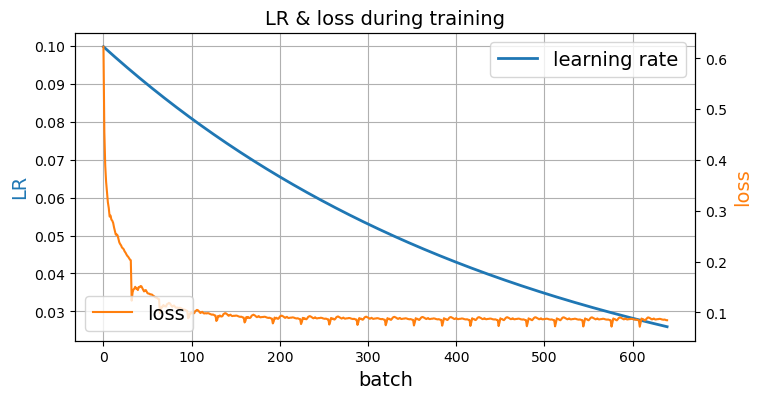

In [125]:
# visualize the learning rate schedule using the list stored in the callback
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8,4))
ax2 = ax1.twinx()

ax1.plot(lr_config.rates, color="C0", label="learning rate", linewidth=2)
ax2.plot(lr_config.losses, color="C1", label="loss")

ax1.set_xlabel("batch")
ax1.set_ylabel("LR", color="C0")
ax2.set_ylabel("loss", color="C1")

ax1.grid(True)
ax1.legend(loc="upper right")
ax2.legend(loc="lower left")

plt.title("LR & loss during training")
plt.show()

### Summary Recommendation
1. **For Prototyping:** Start with `Adam` and a constant LR.
2. **For Refinement:** Use `SGD` with Momentum and Exponential Decay or `ReduceLROnPlateau`.
3. **For Speed:** Implement the `1Cycle` policy if you have a fixed budget of epochs.

---

# Avoiding Overfitting Through Regularization

Regularization reduces a model's tendency to memorize the training set so it generalizes better to new data. This section summarizes the most effective techniques, when to use them, and a compact troubleshooting recipe you can apply to any model.

Why regularize?
- Overfitting arises when model capacity, training time, or label/noise characteristics let the model fit idiosyncrasies of the training set rather than the underlying signal.
- Regularization trades some training accuracy for lower generalization error.

Common techniques (brief)
- Data: more labeled data, smarter data augmentation (strongest and often cheapest payoff).
- Optimization/early stopping: shorter training / monitor validation loss, ReduceLROnPlateau, weight‑averaging.
- Weight regularization: L2 (weight decay), L1 (sparsity).
- Architectural: dropout, batch normalization, smaller networks.
- Label/target: label smoothing, mixup, noise injection.
- Ensembling and distillation: expensive but very effective for final models.
- Pruning and quantization: for deployment (reduces capacity / overfitting in some cases).

Practical recipe
1. Verify overfitting with learning curves (train vs validation).  
2. Fix data issues first (more data, better augmentation, cleaner labels).  
3. Add/strengthen weight decay (start 1e‑4 → 1e‑2) and/or dropout (0.1–0.5) and retune LR.  
4. Use early stopping + save best weights; try ReduceLROnPlateau.  
5. If needed, simplify the model or use ensembling/distillation for production.  
6. Run small ablations (one change at a time) and multiple seeds.

What follows
- Concrete Keras examples: L2 weight decay, dropout, label smoothing, augmentation pipelines, and learning‑curve diagnostics — plus recommended hyperparameter ranges and ablation experiments to quantify impact.

## $\ell_1$ and $\ell_2$ regularization

This code creates a dense layer with 100 neurons using the ReLU activation function and L2 weight regularization (weight decay). The `kernel_regularizer=tf.keras.regularizers.l2(0.01)` argument applies L2 regularization with a factor of 0.01 to the layer's weights, helping to prevent overfitting by penalizing large weights during training.

In [159]:
layer = tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal",
                              kernel_regularizer=tf.keras.regularizers.l2(0.01))

Or use `l1(0.1)` for ℓ<sub>1</sub> regularization with a factor of 0.1, or `l1_l2(0.1, 0.01)` for both ℓ<sub>1</sub> and ℓ<sub>2</sub> regularization, with factors 0.1 and 0.01 respectively.
```python
# Example of using L1 and L2 regularization in Keras
l1_regularizer = tf.keras.regularizers.l1(0.1)
l2_regularizer = tf.keras.regularizers.l2(0.01)
l1_l2_regularizer = tf.keras.regularizers.l1_l2(l1=0.1, l2=0.01)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l1_regularizer),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2_regularizer),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l1_l2_regularizer),
    tf.keras.layers.Dense(10, activation='softmax')
])
```

In [160]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [ ]:
from functools import partial

RegularizedDense = partial(tf.keras.layers.Dense,
                           activation="relu",
                           kernel_initializer="he_normal",
                           kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    RegularizedDense(100),
    RegularizedDense(100),
    RegularizedDense(10, activation="softmax")
])

The code utilizes `functools.partial` to create a "function factory" or a pre-configured version of the `tf.keras.layers.Dense` class. By wrapping the `Dense` layer with specific keyword arguments—`activation`, `kernel_initializer`, and `kernel_regularizer`—you avoid repeating the same configuration for every hidden layer in the network. This approach follows the DRY (Don't Repeat Yourself) principle, making the model architecture more readable and easier to maintain. If you need to change the regularization strength later, you only need to modify it in one location.

The `kernel_regularizer` is set to `tf.keras.regularizers.l2(0.01)`, which applies $\ell_2$ regularization to the weights of the layer. This technique adds a penalty term to the cost function equal to $\alpha \sum_{i=1}^{n} w_i^2$, where $\alpha = 0.01$. This penalty discourages the model from learning overly large weights, which helps mitigate overfitting and forces the model to remain simpler and more generalized. The use of `kernel_initializer="he_normal"` is a best practice when using the `"relu"` activation function, as it helps maintain a stable variance of activations across layers.

In the `tf.keras.Sequential` model, `RegularizedDense(100)` is called twice to create two hidden layers with 100 neurons each, both inheriting the $\ell_2$ regularization and ReLU activation. For the output layer, `RegularizedDense(10, activation="softmax")` is used. This demonstrates that arguments passed directly to the `partial` object during instantiation will override the defaults set in the `partial` definition, allowing the output layer to use the Softmax activation function while still retaining the $\ell_2$ regularization and He initialization.

In [162]:
# extra code – compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7670 - loss: 3.1467 - val_accuracy: 0.8232 - val_loss: 1.8694
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8131 - loss: 1.4296 - val_accuracy: 0.8234 - val_loss: 1.1181


These techniques add a penalty term to the cost function based on the magnitude of the weights.

*   **ℓ₂ Regularization (Weight Decay):** Adds the sum of the squares of the weights.
    $$ J(w) = \text{MSE}(w) + \alpha \frac{1}{2} \sum_{i=1}^{n} w_i^2 $$
*   **ℓ₁ Regularization (Lasso):** Adds the sum of the absolute values of the weights, often leading to sparse models where many weights are exactly zero.
    $$ J(w) = \text{MSE}(w) + \alpha \sum_{i=1}^{n} |w_i| $$

In Keras, you apply these via the `kernel_regularizer` argument in layers, or via the `weight_decay` argument in optimizers (which applies L2 regularization to all weights). The regularization strength ($\alpha$) is a hyperparameter you must tune, typically starting with small values like `1e-4` for L2 and `1e-3` for L1.


In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

Dense_layer = partial(tf.keras.layers.Dense,
                           activation="relu",
                           kernel_initializer="he_normal")

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    Dense_layer(100),
    Dense_layer(100),
    Dense_layer(10, activation="softmax")
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.02, weight_decay=0.01) # extra code – create an optimizer with weight decay
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7767 - loss: 0.6511 - val_accuracy: 0.8326 - val_loss: 0.5015
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8277 - loss: 0.5043 - val_accuracy: 0.8370 - val_loss: 0.4767


---
## Dropout

Dropout randomly zeroes activations during training to prevent co‑adaptation of neurons — effectively performing model-averaging and reducing overfitting.

- When to use: large fully‑connected layers or when validation gap indicates overfitting; less useful if you already have strong augmentation, large datasets, or heavy weight decay.
- Typical rates: dense layers 0.3–0.5; convolutional layers 0.1–0.3; start small and sweep.
- Placement: usually after the activation of a layer (e.g., Dense→Activation→Dropout). Avoid pairing aggressively with BatchNorm (BatchNorm often reduces the need for dropout).
- Training vs inference: dropout is active only during training; Keras uses inverted dropout so no extra scaling is needed at test time.
- Tuning tips: tune dropout together with learning rate and weight decay; more dropout often requires longer training or a slightly higher LR.
- Debugging: if training accuracy collapses, lower the rate or increase model capacity; if validation is noisy, try larger batch size, stronger augmentation, or ReduceLROnPlateau.
- Advanced: use Monte‑Carlo (MC) Dropout for uncertainty estimates by keeping dropout active at inference (run multiple stochastic forward passes and average).

Example (Keras):
```python
tf.keras.layers.Dense(100, activation="relu"),
tf.keras.layers.Dropout(0.5)
```

Quick MC‑Dropout inference pattern:
```python
# run `model(x, training=True)` several times and compute mean/std of outputs
```

In [164]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(rate=0.2), # add a Dropout layer with a dropout rate of 0.2
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [10]:
# extra code – compile and train the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7508 - loss: 0.6725 - val_accuracy: 0.8344 - val_loss: 0.4411
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8130 - loss: 0.5125 - val_accuracy: 0.8444 - val_loss: 0.4095
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8235 - loss: 0.4782 - val_accuracy: 0.8496 - val_loss: 0.4020
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8349 - loss: 0.4484 - val_accuracy: 0.8548 - val_loss: 0.3829
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8381 - loss: 0.4375 - val_accuracy: 0.8624 - val_loss: 0.3760
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8437 - loss: 0.4225 - val_accuracy: 0.8554 - val_loss: 0.3801
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8453 - loss: 0.4190 - val_accuracy: 0.8664 - val_loss: 0.3536
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8485 - loss: 0.4059 - 

The training accuracy looks like it's lower than the validation accuracy, but that's just because dropout is only active during training. If we evaluate the model on the training set after training (i.e., with dropout turned off), we get the "real" training accuracy, which is very slightly higher than the validation accuracy and the test accuracy:

In [11]:
model.evaluate(X_train, y_train)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8811 - loss: 0.3195


[0.31948742270469666, 0.8811454772949219]

In [12]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8606 - loss: 0.3744


[0.3743661642074585, 0.8605999946594238]

**Note**: make sure to use `AlphaDropout` instead of `Dropout` if you want to build a self-normalizing neural net using SELU.

Dropout is a highly effective technique where, during each training step, every neuron (except output neurons) has a probability $p$ of being temporarily "dropped out" (ignored).

*   **Logic**: This prevents neurons from co-adapting and forces them to be more robust.
*   **Gotcha**: Dropout is only active during training. At inference, all neurons are used, and their output is scaled by $(1-p)$.


## MC Dropout (Monte Carlo Dropout)
MC Dropout (Monte Carlo Dropout) is a technique used to estimate uncertainty in neural network predictions by applying dropout during both training and inference. This allows the model to generate multiple stochastic forward passes, providing a distribution of outputs that can be analyzed for uncertainty quantification.

To implement MC Dropout in Keras, you can create a custom dropout layer that remains active during inference. Here's an example of how to do this:

In [13]:
tf.random.set_seed(42)  # extra code – for reproducibility

In [21]:
print(f"Shape of X_test: {X_test.shape}")

# Perform a forward pass through the model with training=True to see the effect of Dropout during inference
model(X_test, training=True)

Shape of X_test: (10000, 28, 28)


<tf.Tensor: shape=(10000, 10), dtype=float32, numpy=
array([[8.68338503e-08, 2.63326019e-08, 2.88771620e-08, ...,
        3.60794924e-02, 1.80486677e-06, 3.49995911e-01],
       [8.79692452e-05, 3.66700874e-07, 9.83430982e-01, ...,
        6.05392889e-11, 6.29578778e-07, 6.68538025e-09],
       [7.98251207e-08, 9.99990463e-01, 3.85612395e-08, ...,
        9.13242548e-09, 2.93259426e-08, 2.10578971e-10],
       ...,
       [6.84869941e-03, 1.32602261e-04, 1.29059146e-04, ...,
        1.00584998e-06, 9.81292009e-01, 6.44379406e-06],
       [1.35286164e-08, 9.99999166e-01, 4.84363616e-09, ...,
        1.12524718e-08, 5.41366862e-09, 1.91521932e-09],
       [1.71922194e-03, 1.05797546e-03, 1.14880165e-03, ...,
        2.28333101e-01, 3.30465175e-02, 2.72686910e-02]], dtype=float32)>

The output of the code cell above provides information about the shape of the test dataset and the results of performing a forward pass on the model with dropout active during inference.

### Shape of `X_test`

The line `Shape of X_test: (10000, 28, 28)` indicates that `X_test` is a NumPy array representing the test dataset.
*   It contains `10000` images.
*   Each image has a resolution of `28x28` pixels.

### Output of `model(X_test, training=True)`

The subsequent output, referred to as `y_proba` (implicitly, as it's the direct return value), is a `numpy.ndarray` with a shape of `(10000, 10)`. This array represents the model's predicted probability distribution for each of the 10,000 test images across the 10 possible output classes.

**Key aspect: `training=True`**

When you call `model(X_test, training=True)`, you are explicitly instructing Keras to run the model in "training mode," even though you are performing an inference task (predicting on `X_test`).
*   For layers like `tf.keras.layers.Dropout`, `training=True` means that **dropout is active**, and neurons are randomly dropped out during this forward pass.
*   This is crucial for implementing **MC Dropout (Monte Carlo Dropout)**, where the goal is to obtain multiple stochastic predictions by keeping dropout active at inference time. Each call with `training=True` will yield slightly different probability distributions due to the random nature of dropout, allowing for uncertainty estimation.
*   If `training` were `False` (the default for `model.predict()` or `model()` without the argument), dropout layers would be inactive, and all neurons would contribute to the prediction (with their outputs scaled by `(1-rate)`).

Therefore, `y_proba` is a set of 10,000 probability vectors, each representing a single, dropout-affected prediction for a given test image. The variance in predictions across multiple such calls is what MC Dropout leverages for uncertainty quantification.

In [15]:
import numpy as np

y_probas = np.stack([model(X_test, training=True)
                     for sample in range(100)])
y_proba = y_probas.mean(axis=0)

In [23]:
print(f"Shape of y_probas: {y_probas.shape}")
print(f"Shape of y_proba: {y_proba.shape}")

Shape of y_probas: (100, 10000, 10)
Shape of y_proba: (10000, 10)


In [28]:
model.predict(X_test[:1]).round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.09 , 0.   , 0.044, 0.   ,
        0.866]], dtype=float32)

The code `model.predict(X_test[:1]).round(3)` executes a standard inference pass on the first sample of the test dataset. The predict method is the high-level Keras API designed for generating predictions. It is optimized for batch processing and returns the output as a NumPy array. During this execution, the model operates in inference mode (*training=False*), which ensures that layers like Dropout are disabled and BatchNormalization uses its learned moving statistics to provide a deterministic output.

In [29]:
model(X_test[:1], training=True).numpy().round(3)

array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.17 , 0.001, 0.098, 0.006,
        0.724]], dtype=float32)

Whereas `model(X_test[:1], training=True).numpy().round(3)` directly calls the model with `training=True`, which forces the model to run in training mode. This means that any Dropout layers will be active, randomly zeroing out some of the activations, and BatchNormalization layers will use the statistics of the current batch instead of the moving averages. As a result, the output will be stochastic and can vary between calls, even for the same input, due to the randomness introduced by dropout.

In [172]:
y_proba[0].round(3)

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.072, 0.   , 0.144, 0.   ,
       0.782], dtype=float32)

The expression `y_proba[0].round(3)` is used to inspect the predicted class probabilities for the first sample in a dataset. In this context, `y_proba` is typically a NumPy array or a tensor returned by a model's `predict()` method, where each row corresponds to an input instance and each column corresponds to a class probability.

The index `[0]` extracts the vector of probabilities for the very first instance. Each value in this vector represents the model's estimated probability $P(y=k | \mathbf{x})$ for class $k$. The `.round(3)` method is then applied to round these floating-point values to three decimal places. This makes the output much easier to read within the VS Code integrated terminal or notebook editor, especially when dealing with the high-precision outputs of a Softmax activation function.

Mathematically, since this is usually the output of a Softmax layer, the elements in `y_proba[0]` satisfy the property:

$$\sum_{j=1}^{K} \hat{y}_j = 1$$

where $K$ is the total number of classes. Rounding helps in quickly identifying the dominant class and assessing the model's confidence without the visual clutter of long decimal expansions.

In [173]:
y_std = y_probas.std(axis=0)
y_std[0].round(3)

array([0.002, 0.001, 0.001, 0.002, 0.001, 0.09 , 0.003, 0.131, 0.001,
       0.147], dtype=float32)

It calculates the standard deviation of probability distributions, which is a common technique in Bayesian approximation methods like Monte Carlo (MC) Dropout. In this context, `y_probas` is typically a 3D array representing multiple prediction passes for the same set of data. By computing the standard deviation, the code quantifies the model's uncertainty for each class prediction.

The line `y_std = y_probas.std(axis=0)` calculates the standard deviation across the first axis. If `y_probas` has the shape $(T, N, K)$, where $T$ is the number of MC samples (stochastic forward passes), $N$ is the number of instances, and $K$ is the number of classes, then `axis=0` collapses the $T$ dimension. The resulting `y_std` array has shape $(N, K)$, where each entry represents the volatility of the model's softmax output across different passes for a specific instance and class.

The formula for the standard deviation $\sigma$ applied here is:

$$\sigma = \sqrt{\frac{1}{T} \sum_{i=1}^{T} (p_i - \mu)^2}$$

The expression `y_std[0].round(3)` extracts the uncertainty vector for the first instance in the batch and rounds each value to three decimal places. High values in this vector indicate that the model's predictions are inconsistent across different dropout masks, signaling high epistemic uncertainty, while values near zero indicate high confidence or stability in the prediction.

In [ ]:
y_pred = y_proba.argmax(axis=1) # get the predicted class labels by taking the argmax of the average predicted probabilities
accuracy = (y_pred == y_test).sum() / len(y_test) # calculate the accuracy by comparing predicted labels with true labels
accuracy

0.8621

**MC Dropout** is a technique used to estimate the **prediction uncertainty** of a neural network without retraining the model.

#### 1. Core Principle
In standard Dropout, neurons are randomly dropped only during the training phase; during inference, all neurons remain active.

**MC Dropout works differently**: it keeps Dropout active during inference as well.

* It performs $T$ inference passes on the same input.
* Since each pass randomly drops different neurons, it produces $T$ slightly different outputs.
* This is equivalent to sampling from a "model distribution," effectively simulating the behavior of ensemble learning.

#### 2. Mathematical Representation
Assume we perform $T$ stochastic inference passes on the same input, obtaining a set of predictions $\{\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_T\}$.

* **Final prediction**: take the mean
    $$\hat{y}_{\text{mean}} = \frac{1}{T} \sum_{t=1}^{T} \hat{y}_t$$

* **Prediction uncertainty**: take the standard deviation or variance
    $$\sigma^2 = \frac{1}{T} \sum_{t=1}^{T} (\hat{y}_t - \hat{y}_{\text{mean}})^2$$

If $\sigma$ is large, it indicates that the model has higher uncertainty about that prediction.

### 3. Building a Dedicated MC Dropout Layer

If you want the model to automatically enable MC Dropout when calling `predict()`, you can define a custom layer:

In [33]:
class MCDropout(tf.keras.layers.Dropout):
    """A Dropout layer that remains active during inference to enable Monte Carlo Dropout."""
    def call(self, inputs, training=None):
        # Override the call method to ensure dropout is applied during inference (training=False).
        # We explicitly set training=True for the parent Dropout layer to keep it active.
        # The 'training' argument passed to this method is intentionally ignored for MC Dropout behavior.
        _ = training  # Acknowledge the parameter to satisfy linters if it's not used otherwise.
        return super().call(inputs, training=True)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,222 (700.09 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 89,612 (350.05 KB)

In [35]:
# extra code – shows how to convert Dropout to MCDropout in a Sequential model
Dropout = tf.keras.layers.Dropout
mc_model = tf.keras.Sequential([
    MCDropout(layer.rate) if isinstance(layer, Dropout) else layer
    for layer in model.layers
])
mc_model.set_weights(model.get_weights())

In [36]:
mc_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout (MCDropout)          │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_1 (MCDropout)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_2 (MCDropout)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

Now we can use the model with MC Dropout:

In [37]:
# extra code – shows that the model works without retraining
tf.random.set_seed(42)
y_proba0 = np.array([mc_model.predict(X_test[:1]) for sample in range(100)])
np.mean(y_proba0, axis=0).round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.31, 0.  , 0.05, 0.  , 0.64]],
      dtype=float32)

In [38]:
np.std(y_proba0, axis=0).round(3)

array([[0.   , 0.   , 0.   , 0.002, 0.   , 0.286, 0.001, 0.059, 0.002,
        0.279]], dtype=float32)

Here, we perform 100 stochastic forward passes of the mc_model on the same input `X_test[:1]`. Each pass will yield a different output due to the active dropout, allowing us to compute both the mean prediction and the uncertainty (standard deviation) across these passes. The mean gives us the final class probabilities, while the standard deviation provides insight into how confident the model is about its predictions.

---
## Max norm
Max norm regularization **constrains the maximum norm of the weights** in each layer to a specified value, preventing them from growing too large and helping to reduce overfitting. This technique can improve generalization by keeping the model's capacity in check.

In [179]:
dense = tf.keras.layers.Dense(
    100, activation="relu", kernel_initializer="he_normal",
    kernel_constraint=tf.keras.constraints.max_norm(1.))

`tf.keras.constraints.max_norm(1.)` here creates a max norm constraint with a maximum norm of 1.0. When applied to a layer by specifying it in the `kernel_constraint` argument, it ensures that the weights of that layer do not exceed this norm during training. If the weights exceed the specified norm, they are scaled down to fit within the limit.

In [ ]:
# extra code – shows how to apply max norm to every hidden layer in a model

# We can use functools.partial to create a new Dense layer class that has the max norm constraint already applied, and then use this new class to build our model.
MaxNormDense = partial(tf.keras.layers.Dense,
                       activation="relu", kernel_initializer="he_normal",
                       kernel_constraint=tf.keras.constraints.max_norm(1.))

tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28]),
    tf.keras.layers.Flatten(),
    MaxNormDense(100),
    MaxNormDense(100),
    tf.keras.layers.Dense(10, activation="softmax")
])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8008 - loss: 0.5553 - val_accuracy: 0.8308 - val_loss: 0.4390
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8485 - loss: 0.4114 - val_accuracy: 0.8356 - val_loss: 0.4177
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8601 - loss: 0.3802 - val_accuracy: 0.8412 - val_loss: 0.4019
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8665 - loss: 0.3605 - val_accuracy: 0.8434 - val_loss: 0.4065
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8701 - loss: 0.3485 - val_accuracy: 0.8394 - val_loss: 0.4138
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8731 - loss: 0.3392 - val_accuracy: 0.8458 - val_loss: 0.4000
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8747 - loss: 0.3348 - val_accuracy: 0.8380 - val_loss: 0.4066
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8758 - loss: 0.3294 - 

Summary Table

| Technique            | When to use             | Primary Effect                 |
| :------------------- | :---------------------- | :----------------------------- |
| ℓ₂ Regularization    | Small/Medium datasets   | Keeps weights small            |
| Dropout              | Deep neural networks    | Reduces neuronal co-dependency |
| Early Stopping       | Almost always           | Prevents training for too many epochs |
| Data Augmentation    | Image/Audio tasks       | Increases effective training set size |


---

# Exercises

## 1. to 7.

1. Glorot initialization and He initialization were designed to make the output standard deviation as close as possible to the input standard deviation, at least at the beginning of training. This reduces the vanishing/exploding gradients problem.
2. No, all weights should be sampled independently; they should not all have the same initial value. One important goal of sampling weights randomly is to break symmetry: if all the weights have the same initial value, even if that value is not zero, then symmetry is not broken (i.e., all neurons in a given layer are equivalent), and backpropagation will be unable to break it. Concretely, this means that all the neurons in any given layer will always have the same weights. It's like having just one neuron per layer, and much slower. It is virtually impossible for such a configuration to converge to a good solution.
3. It is perfectly fine to initialize the bias terms to zero. Some people like to initialize them just like weights, and that's OK too; it does not make much difference.
4. ReLU is usually a good default for the hidden layers, as it is fast and yields good results. Its ability to output precisely zero can also be useful in some cases (e.g., see Chapter 17). Moreover, it can sometimes benefit from optimized implementations as well as from hardware acceleration. The leaky ReLU variants of ReLU can improve the model's quality without hindering its speed too much compared to ReLU. For large neural nets and more complex problems, GLU, Swish and Mish can give you a slightly higher quality model, but they have a computational cost. The hyperbolic tangent (tanh) can be useful in the output layer if you need to output a number in a fixed range (by default between –1 and 1), but nowadays it is not used much in hidden layers, except in recurrent nets. The sigmoid activation function is also useful in the output layer when you need to estimate a probability (e.g., for binary classification), but it is rarely used in hidden layers (there are exceptions—for example, for the coding layer of variational autoencoders; see Chapter 17). The softplus activation function is useful in the output layer when you need to ensure that the output will always be positive. The softmax activation function is useful in the output layer to estimate probabilities for mutually exclusive classes, but it is rarely (if ever) used in hidden layers.
5. If you set the `momentum` hyperparameter too close to 1 (e.g., 0.99999) when using an `SGD` optimizer, then the algorithm will likely pick up a lot of speed, hopefully moving roughly toward the global minimum, but its momentum will carry it right past the minimum. Then it will slow down and come back, accelerate again, overshoot again, and so on. It may oscillate this way many times before converging, so overall it will take much longer to converge than with a smaller `momentum` value.
6. One way to produce a sparse model (i.e., with most weights equal to zero) is to train the model normally, then zero out tiny weights. For more sparsity, you can apply ℓ<sub>1</sub> regularization during training, which pushes the optimizer toward sparsity. A third option is to use the TensorFlow Model Optimization Toolkit.
7. Yes, dropout does slow down training, in general roughly by a factor of two. However, it has no impact on inference speed since it is only turned on during training. MC Dropout is exactly like dropout during training, but it is still active during inference, so each inference is slowed down slightly. More importantly, when using MC Dropout you generally want to run inference 10 times or more to get better predictions. This means that making predictions is slowed down by a factor of 10 or more.

---

## 8. Deep Learning on CIFAR10

In this exercise, you will build and train a deep neural network on the CIFAR10 dataset (60,000 32×32 color images in 10 classes) using TensorFlow/Keras. You will start with a baseline model and progressively apply techniques covered in this chapter to improve generalization and prevent overfitting, such as data augmentation, weight regularization (L2, dropout, max norm), and advanced optimizers and learning rate scheduling. The workflow includes loading and preprocessing the data, defining and compiling the model, training with callbacks (e.g., early stopping, learning rate schedulers), and evaluating performance on the test set. Experiment with hyperparameter tuning and regularization strategies to achieve strong test accuracy, aiming for at least 80%.

### a.
*Exercise: Build a DNN with 20 hidden layers of 100 neurons each (that's too many, but it's the point of this exercise). Use He initialization and the Swish activation function.*

In [24]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[32, 32, 3]))
model.add(tf.keras.layers.Flatten())
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    activation="swish",
                                    kernel_initializer="he_normal"))

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 100)            │        10,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 499,200 (1.90 MB)

 Trainable params: 499,200 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

### b.
*Exercise: Using Nadam optimization and early stopping, train the network on the CIFAR10 dataset. You can load it with `tf.keras.datasets.cifar10.load_data()`. The dataset is composed of 60,000 32 × 32–pixel color images (50,000 for training, 10,000 for testing) with 10 classes, so you'll need a softmax output layer with 10 neurons. Remember to search for the right learning rate each time you change the model's architecture or hyperparameters.*

Let's add the output layer to the model:

In [26]:
model.add(tf.keras.layers.Dense(10, activation="softmax"))

Let's use a Nadam optimizer with a learning rate of 5e-5. I tried learning rates 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3 and 1e-2, and I compared their learning curves for 10 epochs each (using the TensorBoard callback, below). The learning rates 3e-5 and 1e-4 were pretty good, so I tried 5e-5, which turned out to be slightly better.

In [27]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-5)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

Let's load the CIFAR10 dataset. We also want to use early stopping, so we need a validation set. Let's use the first 5,000 images of the original training set as the validation set:

In [5]:
cifar10 = tf.keras.datasets.cifar10.load_data()
(X_train_full, y_train_full), (X_test, y_test) = cifar10

X_train = X_train_full[5000:]
y_train = y_train_full[5000:]
X_valid = X_train_full[:5000]
y_valid = y_train_full[:5000]

This dataset contains 50,000 training images and 10,000 test images. The training set is further split into 45,000 training images and 5,000 validation images. Each image is a 32×32 pixel color image (3 channels), and there are 10 classes. The classes are typically labeled as follows: 0 = airplane, 1 = automobile, 2 = bird, 3 = cat, 4 = deer, 5 = dog, 6 = frog, 7 = horse, 8 = ship, and 9 = truck. The dataset is commonly used for benchmarking image classification algorithms and is available in TensorFlow/Keras through `tf.keras.datasets.cifar10.load_data()`.

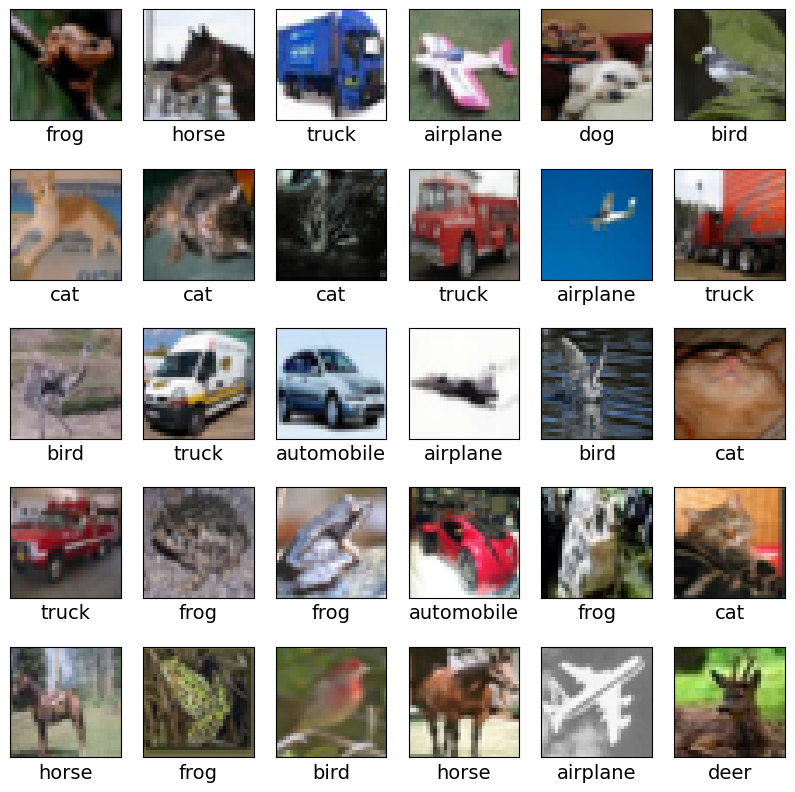

In [29]:
# visualize the first 30 images in the training set along with their labels
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
plt.figure(figsize=(10, 10))
for i in range(30):
    plt.subplot(5, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()


Now we can create the callbacks we need and train the model:

In [30]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_cifar10_model.keras",
                                                         save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

In [15]:
%load_ext tensorboard
%tensorboard --logdir=./my_cifar10_logs

Reusing TensorBoard on port 6006 (pid 23036), started 13:18:48 ago. (Use '!kill 23036' to kill it.)

In [31]:
model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.1608 - loss: 3.9985 - val_accuracy: 0.2150 - val_loss: 2.1665
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2363 - loss: 2.0785 - val_accuracy: 0.2744 - val_loss: 1.9968
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2767 - loss: 1.9657 - val_accuracy: 0.3084 - val_loss: 1.9191
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3062 - loss: 1.8915 - val_accuracy: 0.3188 - val_loss: 1.8701
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3310 - loss: 1.8313 - val_accuracy: 0.3612 - val_loss: 1.7886
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3529 - loss: 1.7826 - val_accuracy: 0.3602 - val_loss: 1.7692
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3699 - loss: 1.7361 - val_accuracy: 0.3828 - val_loss: 1.7215
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3861 - loss: 

In [32]:
model.evaluate(X_valid, y_valid)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4308 - loss: 1.5897


[1.5896512269973755, 0.4307999908924103]

The model with the lowest validation loss gets about 46.8% accuracy on the validation set. It took 29 epochs to reach the lowest validation loss, with roughly 10 seconds per epoch on my laptop (without a GPU). Let's see if we can improve the model using Batch Normalization.

### c.
*Exercise: Now try adding Batch Normalization and compare the learning curves: Is it converging faster than before? Does it produce a better model? How does it affect training speed?*

The code below is very similar to the code above, with a few changes:

* I added a BN layer after every Dense layer (before the activation function), except for the output layer.
* I changed the learning rate to 5e-4. I experimented with 1e-5, 3e-5, 5e-5, 1e-4, 3e-4, 5e-4, 1e-3 and 3e-3, and I chose the one with the best validation performance after 20 epochs.
* I renamed the run directories to run_bn_* and the model file name to `my_cifar10_bn_model`.

In [6]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[32, 32, 3]))
model.add(tf.keras.layers.Flatten())
for _ in range(20):
    model.add(tf.keras.layers.Dense(100, kernel_initializer="he_normal"))
    model.add(tf.keras.layers.BatchNormalization()) # add a BatchNormalization layer after each Dense layer
    model.add(tf.keras.layers.Activation("swish"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 508,210 (1.94 MB)

 Trainable params: 504,210 (1.92 MB)

 Non-trainable params: 4,000 (15.62 KB)

In [8]:

optimizer = tf.keras.optimizers.Nadam(learning_rate=7e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [9]:

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_cifar10_bn_model.keras",
                                                         save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_bn_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.2716 - loss: 2.0014 - val_accuracy: 0.3028 - val_loss: 1.8993
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.3700 - loss: 1.7490 - val_accuracy: 0.3002 - val_loss: 2.0269
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4149 - loss: 1.6379 - val_accuracy: 0.3764 - val_loss: 1.7075
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4451 - loss: 1.5601 - val_accuracy: 0.3596 - val_loss: 1.7663
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4685 - loss: 1.4931 - val_accuracy: 0.3560 - val_loss: 1.8706
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4925 - loss: 1.4298 - val_accuracy: 0.3616 - val_loss: 1.8736
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5159 - loss: 1.3687 - val_accuracy: 0.3732 - val_loss: 1.8525
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 

In [10]:

model.evaluate(X_valid, y_valid)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3764 - loss: 1.7075


[1.7075287103652954, 0.3763999938964844]

* *Is the model converging faster than before?* Much faster! The previous model took 29 epochs to reach the lowest validation loss, while the new model achieved that same loss in just 12 epochs and continued to make progress until the 17th epoch. The BN layers stabilized training and allowed us to use a much larger learning rate, so convergence was faster.
* *Does BN produce a better model?* Yes! The final model is also much better, with 50.7% validation accuracy instead of 46.7%. It's still not a very good model, but at least it's much better than before (a Convolutional Neural Network would do much better, but that's a different topic, see chapter 14).
* *How does BN affect training speed?* Although the model converged much faster, each epoch took about 15s instead of 10s, because of the extra computations required by the BN layers. But overall the training time (wall time) to reach the best model was shortened by about 10%.

In [11]:
%reload_ext tensorboard
%tensorboard --logdir=./my_cifar10_logs

Reusing TensorBoard on port 6006 (pid 23036), started 1 day, 2:06:31 ago. (Use '!kill 23036' to kill it.)

### d.
*Exercise: Try replacing Batch Normalization with SELU, and make the necessary adjustements to ensure the network self-normalizes (i.e., standardize the input features, use LeCun normal initialization, make sure the DNN contains only a sequence of dense layers, etc.).*

In [7]:
X_train.shape

(45000, 32, 32, 3)

In [6]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[32, 32, 3]))
model.add(tf.keras.layers.Flatten())
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=7e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_cifar10_selu_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_selu_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds
X_valid_scaled = (X_valid - X_means) / X_stds
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=100,
          validation_data=(X_valid_scaled, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid_scaled, y_valid)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3182 - loss: 1.9080 - val_accuracy: 0.3450 - val_loss: 1.7837
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3905 - loss: 1.7136 - val_accuracy: 0.3946 - val_loss: 1.7108
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4285 - loss: 1.6177 - val_accuracy: 0.4288 - val_loss: 1.6341
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4554 - loss: 1.5485 - val_accuracy: 0.4478 - val_loss: 1.5884
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4725 - loss: 1.4933 - val_accuracy: 0.4692 - val_loss: 1.5520
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4931 - loss: 1.4442 - val_accuracy: 0.4786 - val_loss: 1.5361
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5104 - loss: 1.4062 - val_accuracy: 0.4784 - val_loss: 1.5423
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5223 

[1.5240123271942139, 0.4864000082015991]

This model reached the first model's validation loss in just 8 epochs. After 14 epochs, it reached its lowest validation loss, with about 50.3% accuracy, which is better than the original model (46.7%), but not quite as good as the model using batch normalization (50.7%). Each epoch took only 9 seconds. So it's the fastest model to train so far.

In [8]:
tf.random.set_seed(42)

normalization_layer = tf.keras.layers.Normalization()
normalization_layer.adapt(X_train)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[32, 32, 3])) # add an Input layer to specify the input shape
model.add(normalization_layer) # add a Normalization layer to standardize the inputs
model.add(tf.keras.layers.Flatten())
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=7e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_cifar10_selu_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_selu_input_layer_norm{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

model.evaluate(normalization_layer(X_valid), y_valid)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.3146 - loss: 1.9196 - val_accuracy: 0.3486 - val_loss: 1.8139
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.3885 - loss: 1.7180 - val_accuracy: 0.4216 - val_loss: 1.6528
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4295 - loss: 1.6194 - val_accuracy: 0.4298 - val_loss: 1.6240
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4523 - loss: 1.5528 - val_accuracy: 0.4404 - val_loss: 1.6058
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4752 - loss: 1.5009 - val_accuracy: 0.4612 - val_loss: 1.5894
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4945 - loss: 1.4473 - val_accuracy: 0.4720 - val_loss: 1.5567
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5096 - loss: 1.4079 - val_accuracy: 0.4742 - val_loss: 1.5265
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0

[2.561392068862915, 0.10379999876022339]

### e.
*Exercise: Try regularizing the model with alpha dropout. Then, without retraining your model, see if you can achieve better accuracy using MC Dropout.*

**Warning**: there are now two versions of `AlphaDropout`. One is deprecated and also broken in some recent versions of TF, and unfortunately that's the version in the `tensorflow` library. Luckily, there's a perfectly fine version in the `keras` library (i.e., `keras`, not `tf.keras`). It's neither deprecated nor broken, so let's import and use that one:

In [9]:
import keras.layers

In [10]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[32, 32, 3]))
model.add(tf.keras.layers.Flatten())
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=20, restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "my_cifar10_alpha_dropout_model.keras", save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = Path() / "my_cifar10_logs" / f"run_alpha_dropout_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

X_means = X_train.mean(axis=0)
X_stds = X_train.std(axis=0)
X_train_scaled = (X_train - X_means) / X_stds
X_valid_scaled = (X_valid - X_means) / X_stds
X_test_scaled = (X_test - X_means) / X_stds

model.fit(X_train_scaled, y_train, epochs=100,
          validation_data=(X_valid_scaled, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid_scaled, y_valid)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.3190 - loss: 1.9024 - val_accuracy: 0.3842 - val_loss: 1.7511
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4025 - loss: 1.6804 - val_accuracy: 0.4268 - val_loss: 1.6349
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4432 - loss: 1.5849 - val_accuracy: 0.4410 - val_loss: 1.6139
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4685 - loss: 1.5128 - val_accuracy: 0.4642 - val_loss: 1.5758
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4918 - loss: 1.4554 - val_accuracy: 0.4680 - val_loss: 1.5659
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5110 - loss: 1.4051 - val_accuracy: 0.4782 - val_loss: 1.5886
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5286 - loss: 1.3625 - val_accuracy: 0.4802 - val_loss: 1.6526
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.540

[1.5659383535385132, 0.46799999475479126]

The model reaches 48.1% accuracy on the validation set. That's worse than without dropout (50.3%). With an extensive hyperparameter search, it might be possible to do better (I tried dropout rates of 5%, 10%, 20% and 40%, and learning rates 1e-4, 3e-4, 5e-4, and 1e-3), but probably not much better in this case.

Let's use MC Dropout now. We will need the `MCAlphaDropout` class we used earlier, so let's just copy it here for convenience:

In [11]:
class MCAlphaDropout(keras.layers.AlphaDropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

Now let's create a new model, identical to the one we just trained (with the same weights), but with `MCAlphaDropout` dropout layers instead of `AlphaDropout` layers:

In [12]:
mc_model = tf.keras.Sequential([
    (
        MCAlphaDropout(layer.rate)
        if isinstance(layer, keras.layers.AlphaDropout)
        else layer
    )
    for layer in model.layers
])

Then let's add a couple utility functions. The first will run the model many times (10 by default) and it will return the mean predicted class probabilities. The second will use these mean probabilities to predict the most likely class for each instance:

In [15]:
import numpy as np

def mc_dropout_predict_probas(mc_model, X, n_samples=10):
    Y_probas = [mc_model.predict(X) for sample in range(n_samples)]
    return np.mean(Y_probas, axis=0)

def mc_dropout_predict_classes(mc_model, X, n_samples=10):
    Y_probas = mc_dropout_predict_probas(mc_model, X, n_samples)
    return Y_probas.argmax(axis=1)

Now let's make predictions for all the instances in the validation set, and compute the accuracy:

In [16]:
tf.random.set_seed(42)

y_pred = mc_dropout_predict_classes(mc_model, X_valid_scaled)
accuracy = (y_pred == y_valid[:, 0]).mean()
accuracy

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


0.4678

We get back to roughly the accuracy of the model without dropout in this case (about 50.3% accuracy).

So the best model we got in this exercise is the Batch Normalization model.

### f.
*Exercise: Retrain your model using 1cycle scheduling and see if it improves training speed and model accuracy.*

In [25]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[32, 32, 3]))
model.add(tf.keras.layers.Flatten())
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                    kernel_initializer="lecun_normal",
                                    activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.SGD()
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1709 - loss: nan


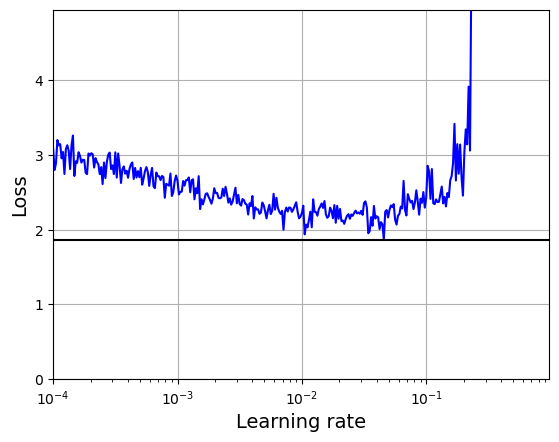

In [37]:
batch_size = 128
rates, losses = find_learning_rate(model, X_train_scaled, y_train, epochs=1,
                                   batch_size=batch_size)
plot_lr_vs_loss(rates, losses)

In [38]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[32, 32, 3]))
model.add(tf.keras.layers.Flatten())
for _ in range(20):
    model.add(tf.keras.layers.Dense(100,
                                 kernel_initializer="lecun_normal",
                                 activation="selu"))

model.add(keras.layers.AlphaDropout(rate=0.1))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.SGD(learning_rate=2e-2)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

In [41]:
n_epochs = 15
n_iterations = math.ceil(len(X_train_scaled) / batch_size) * n_epochs
onecycle = OneCycleScheduler(n_iterations, max_lr=0.05)
history = model.fit(X_train_scaled, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[onecycle])

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2885 - loss: 2.0480 - val_accuracy: 0.3694 - val_loss: 1.7742 - lr: 0.0117
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3709 - loss: 1.7850 - val_accuracy: 0.3982 - val_loss: 1.7224 - lr: 0.0183
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4162 - loss: 1.6407 - val_accuracy: 0.4246 - val_loss: 1.6975 - lr: 0.0250
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4508 - loss: 1.5508 - val_accuracy: 0.4510 - val_loss: 1.6529 - lr: 0.0317
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4702 - loss: 1.4957 - val_accuracy: 0.4284 - val_loss: 1.7548 - lr: 0.0383
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4884 - loss: 1.4475 - val_accuracy: 0.4472 - val_loss: 1.7206 - lr: 0.0450
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4985 - loss: 1.4093 - val_accuracy: 0.4612 - val_loss: 1.6935 - lr: 0.0483
Epoch 8/1

One cycle allowed us to train the model in just 15 epochs, each taking only 2 seconds (thanks to the larger batch size). This is several times faster than the fastest model we trained so far. Moreover, we improved the model's performance (from 50.7% to 52.0%).

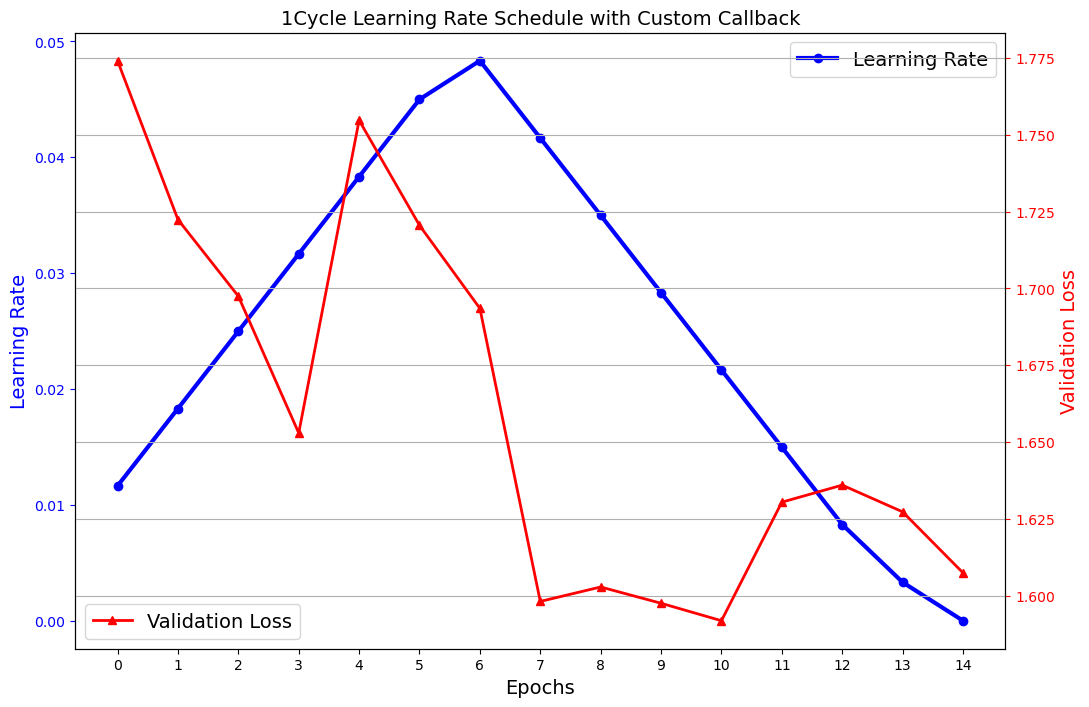

In [44]:
plot_lr_and_loss_from_history(history, n_epochs, title="1Cycle Learning Rate Schedule with Custom Callback")